# Student Academic Performance Prediction Using Machine Learning

## 1. Introduction

Student academic performance is influenced by a combination of academic, behavioral, lifestyle, demographic, and environmental factors. Predicting student performance using machine learning can help identify important performance-related patterns and support data-driven educational decision-making.

This study develops a comprehensive machine learning framework for predicting students' examination scores using demographic characteristics, study habits, lifestyle factors, well-being indicators, and educational background.

The study systematically evaluates multiple machine learning approaches and investigates the effects of data preprocessing, feature engineering, feature selection, and hyperparameter optimization on predictive performance.

## 2. Research Objective

The primary objective of this study is to develop and evaluate machine learning models for predicting students' examination scores based on available student-related attributes.

The study further aims to:

- Compare different machine learning algorithms for student performance prediction.
- Evaluate the effect of domain-informed feature engineering.
- Investigate the impact of feature selection on model performance.
- Optimize selected models using hyperparameter tuning.
- Evaluate model robustness using cross-validation.
- Identify the most influential features affecting predicted student performance.
- Improve the interpretability of machine learning predictions using explainable machine learning techniques.

## 3. Research Questions

1. How accurately can students' examination scores be predicted using machine learning?
2. Which machine learning algorithms provide reliable predictive performance for the given dataset?
3. Does feature engineering improve student performance prediction compared with the original feature set?
4. Can feature selection improve model efficiency while maintaining predictive performance?
5. Which student-related factors contribute most to predicted examination scores?
6. How stable are model predictions across different cross-validation folds?

## 4. Prediction Task

The target variable in this study is `exam_score`.

Since `exam_score` is a continuous numerical variable, the primary prediction task is formulated as a **regression problem**.

In [113]:
# ============================================
# IMPORT REQUIRED LIBRARIES
# ============================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [114]:
# ============================================
# LOAD DATASET
# ============================================

file_path = "/content/drive/MyDrive/student_habits_performance.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [115]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [116]:
# Display dataset dimensions

rows, columns = df.shape

print(f"Number of observations: {rows}")
print(f"Number of columns: {columns}")

Number of observations: 1000
Number of columns: 16


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [118]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,1000,1000,S1999,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,20.498,2.3081,17.0,18.75,20.0,23.0,24.0
gender,1000,3,Female,481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_per_day,1000.0,NaN,NaN,NaN,3.5501,1.46889,0.0,2.6,3.5,4.5,8.3
social_media_hours,1000.0,NaN,NaN,NaN,2.5055,1.172422,0.0,1.7,2.5,3.3,7.2
netflix_hours,1000.0,NaN,NaN,NaN,1.8197,1.075118,0.0,1.0,1.8,2.525,5.4
part_time_job,1000,2,No,785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attendance_percentage,1000.0,NaN,NaN,NaN,84.1317,9.399246,56.0,78.0,84.4,91.025,100.0
sleep_hours,1000.0,NaN,NaN,NaN,6.4701,1.226377,3.2,5.6,6.5,7.3,10.0
diet_quality,1000,3,Fair,437,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [119]:
# ============================================
# MISSING VALUE ANALYSIS
# ============================================

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary.sort_values(
    by="Missing Count",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
parental_education_level,91,9.1
student_id,0,0.0
gender,0,0.0
age,0,0.0
social_media_hours,0,0.0
netflix_hours,0,0.0
part_time_job,0,0.0
study_hours_per_day,0,0.0
attendance_percentage,0,0.0
sleep_hours,0,0.0


In [120]:
# ============================================
# DUPLICATE ANALYSIS
# ============================================

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [121]:
# Check uniqueness of student identifiers

print("Total records:", len(df))
print("Unique student IDs:", df["student_id"].nunique())

Total records: 1000
Unique student IDs: 1000


## Target Variable Analysis

The target variable of the study is `exam_score`, which represents the examination score obtained by each student.

Since the target variable is continuous, the prediction problem is formulated as a regression task.

Before developing predictive models, the distribution and statistical characteristics of the target variable are examined to understand its central tendency, variability, range, and potential distributional issues.

In [122]:
# Descriptive statistics of the target variable

target_stats = {
    "Mean": df["exam_score"].mean(),
    "Median": df["exam_score"].median(),
    "Standard Deviation": df["exam_score"].std(),
    "Minimum": df["exam_score"].min(),
    "Maximum": df["exam_score"].max()
}

pd.Series(target_stats)

,0
Mean,69.601500
Median,70.500000
Standard Deviation,16.888564
Minimum,18.400000
Maximum,100.000000


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the statistical characteristics, distributions, relationships, and potential anomalies present in the dataset before developing machine learning models.

The analysis focuses on the target variable, numerical predictors, categorical predictors, feature relationships, and potential outliers.

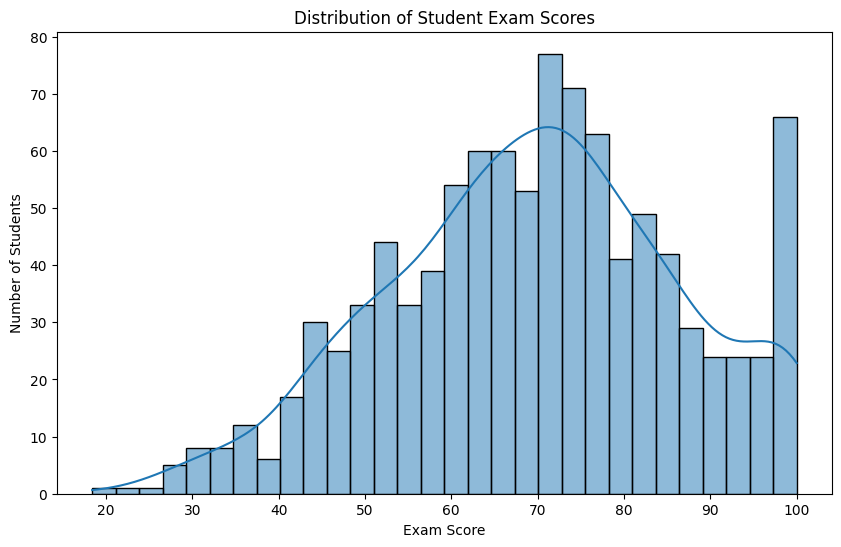

In [123]:
# ============================================
# EXAM SCORE DISTRIBUTION
# ============================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="exam_score",
    bins=30,
    kde=True
)

plt.title("Distribution of Student Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

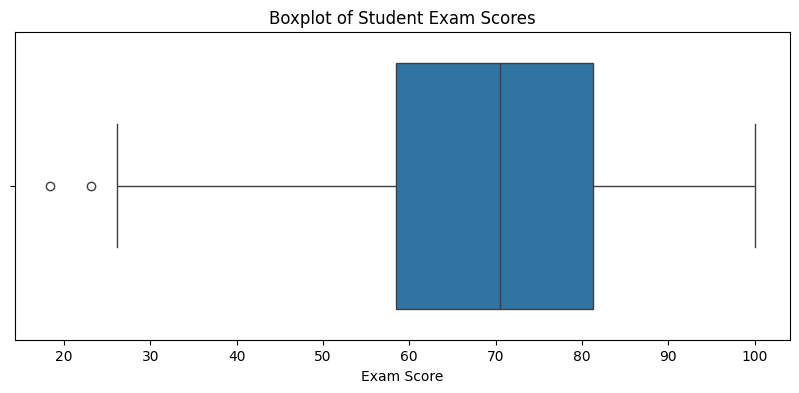

In [124]:
# ============================================
# EXAM SCORE BOXPLOT
# ============================================

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["exam_score"]
)

plt.title("Boxplot of Student Exam Scores")
plt.xlabel("Exam Score")

plt.show()

### Distribution of Numerical Features

The distributions of numerical variables are examined to identify their ranges, variability, skewness, and potential anomalous observations.

Understanding the distribution of each predictor is important for selecting appropriate preprocessing and modelling strategies.

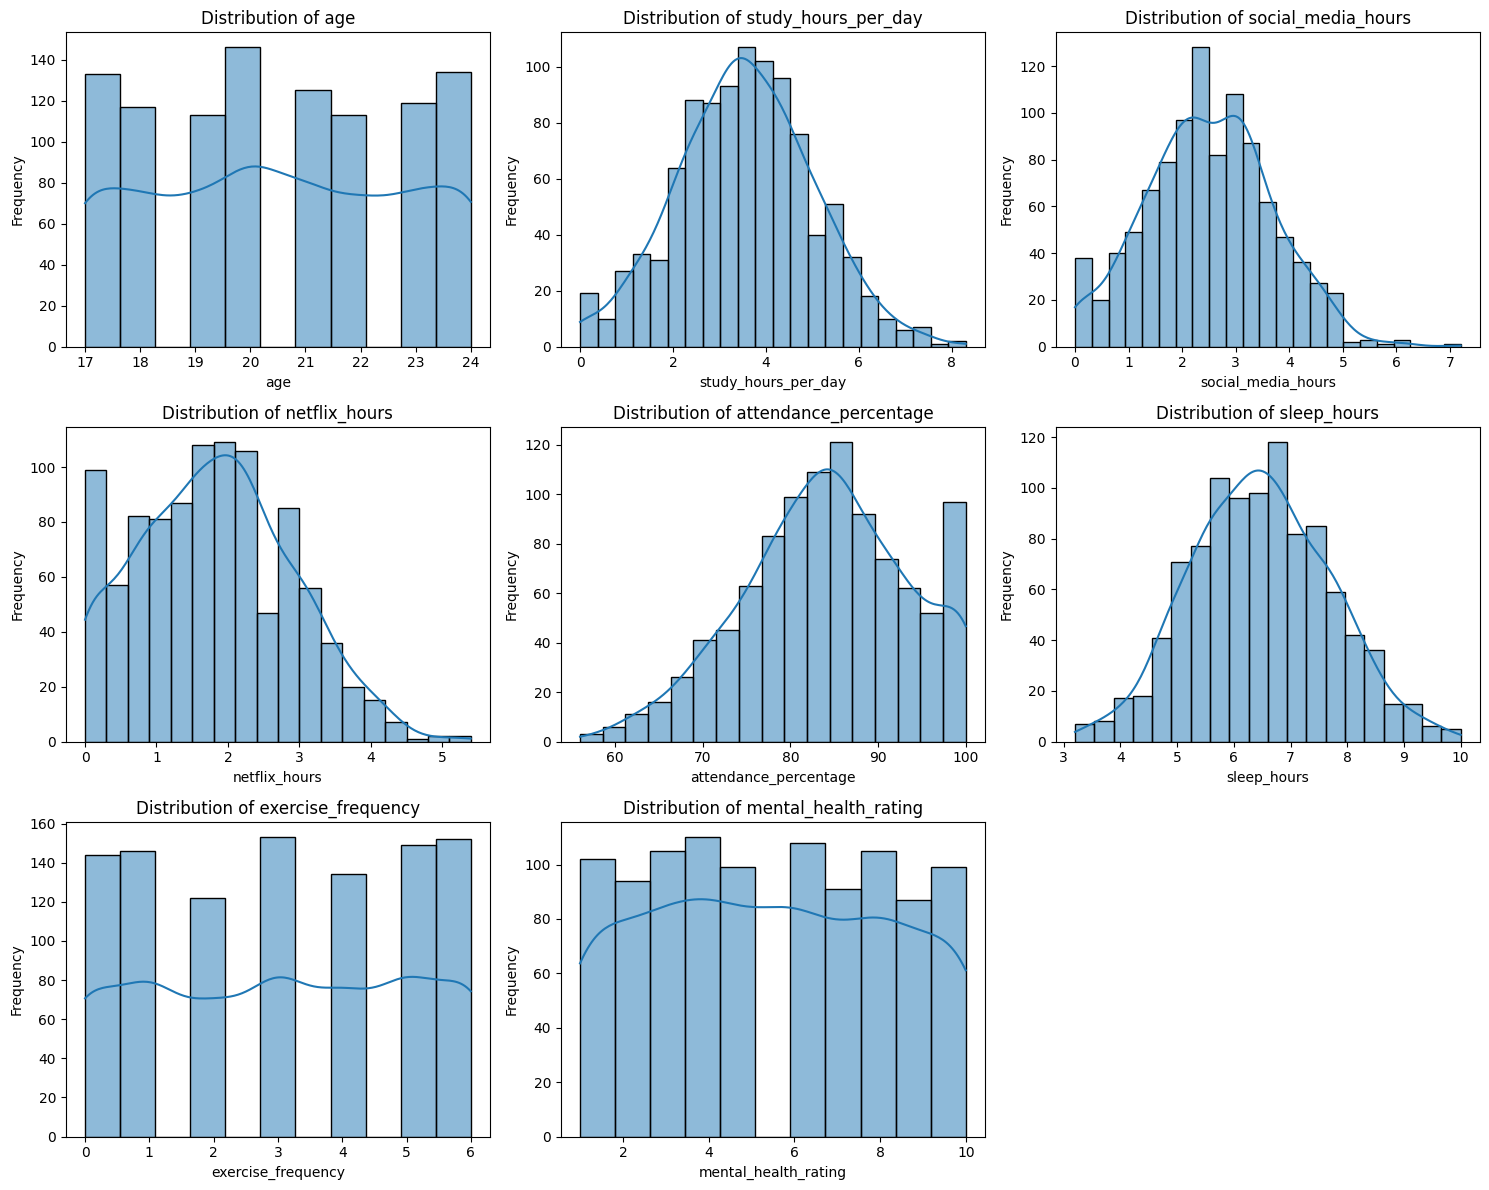

In [125]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15, 12)
)

axes = axes.flatten()

for i, column in enumerate(numerical_features):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

# Remove unused subplot
for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##Relationship Between Numerical Features and Exam Score

The relationship between numerical predictor variables and examination scores is examined using scatter plots and regression lines.

This analysis helps identify potential linear and nonlinear relationships between student characteristics and academic performance.

The observed relationships are interpreted as associations and do not imply causal relationships.

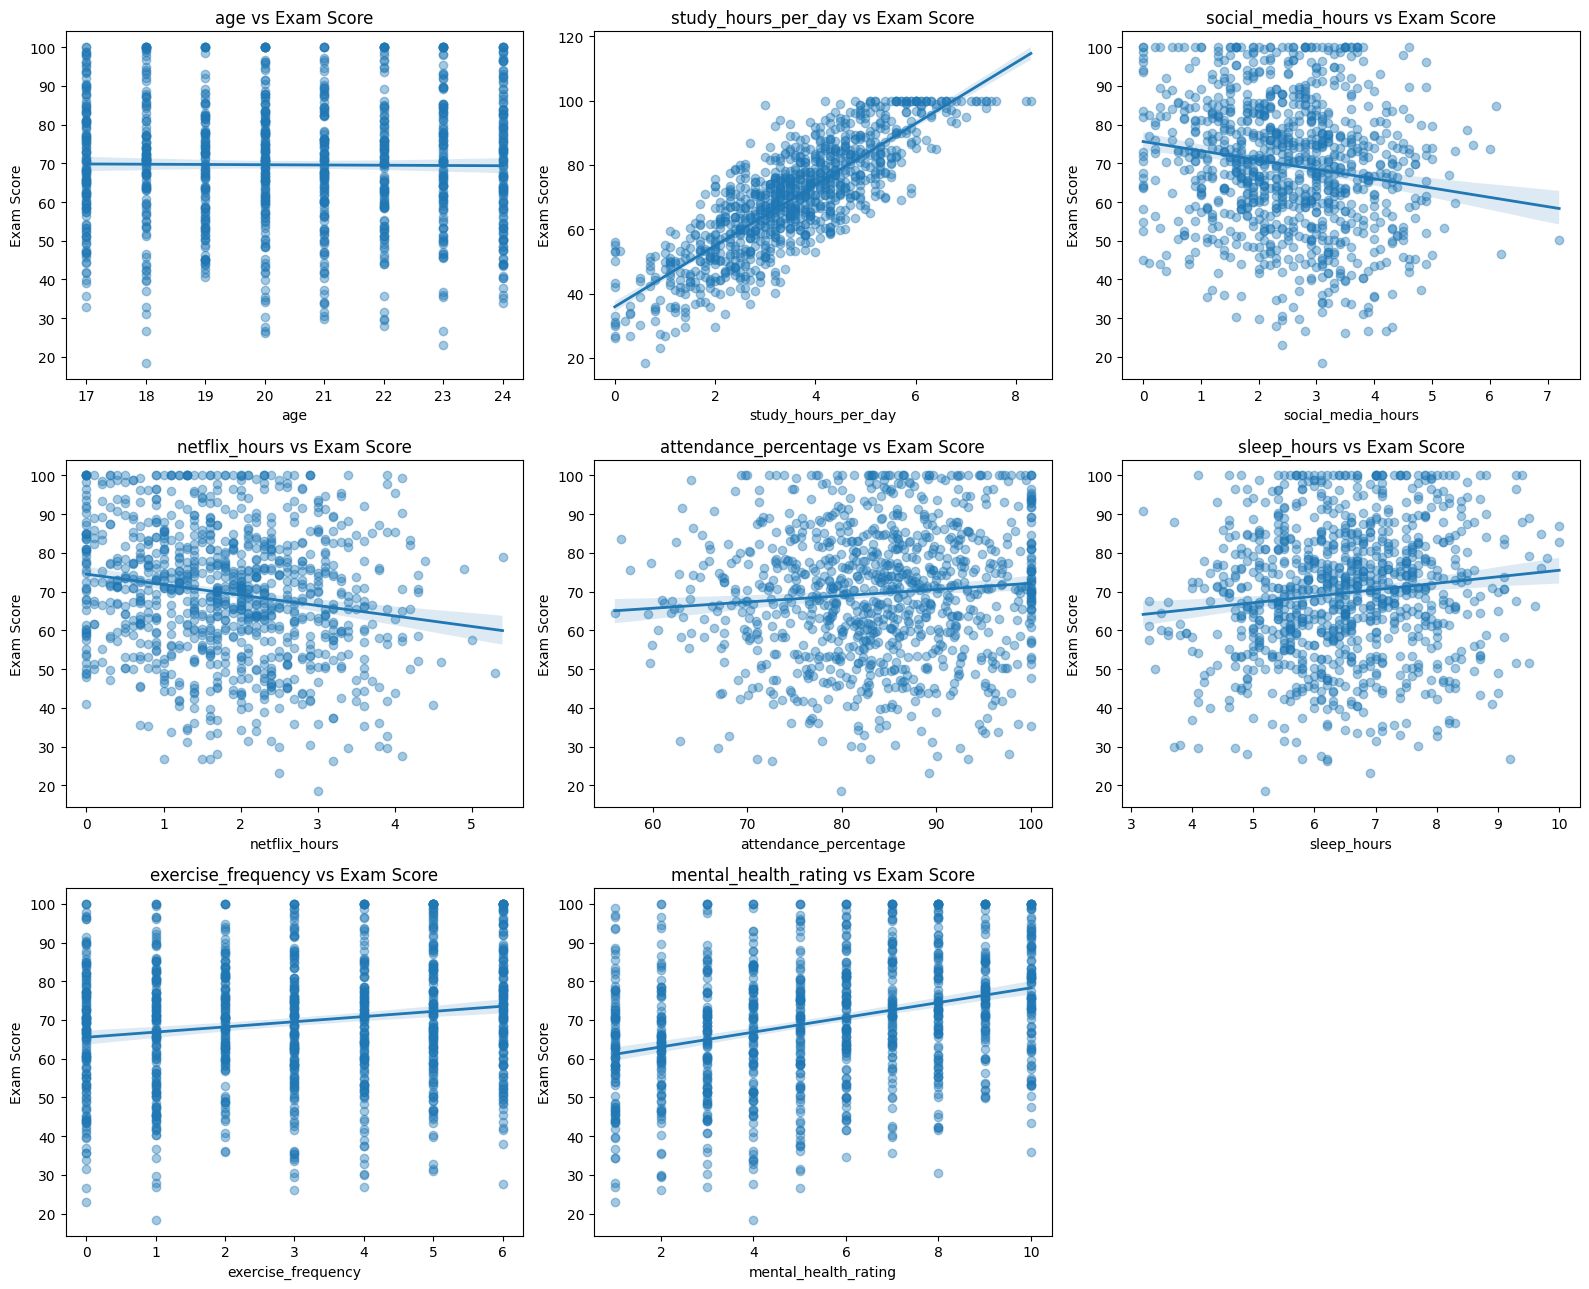

In [126]:
# ============================================
# NUMERICAL FEATURES VS EXAM SCORE
# ============================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(16, 13)
)

axes = axes.flatten()

for i, column in enumerate(numerical_features):

    sns.regplot(
        data=df,
        x=column,
        y="exam_score",
        scatter_kws={"alpha": 0.4},
        line_kws={"linewidth": 2},
        ax=axes[i]
    )

    axes[i].set_title(f"{column} vs Exam Score")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Exam Score")

# Remove unused subplot
for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Categorical Features and Exam Score

The distribution of examination scores across categorical student characteristics is examined using boxplots.

Boxplots are used to compare the median, variability, and distribution of examination scores across different categories. This analysis provides an exploratory understanding of whether categorical characteristics are associated with differences in observed academic performance.

In [127]:
# Define categorical features

categorical_features = [
    "gender",
    "part_time_job",
    "diet_quality",
    "parental_education_level",
    "internet_quality",
    "extracurricular_participation"
]

print("Categorical features defined successfully.")

Categorical features defined successfully.


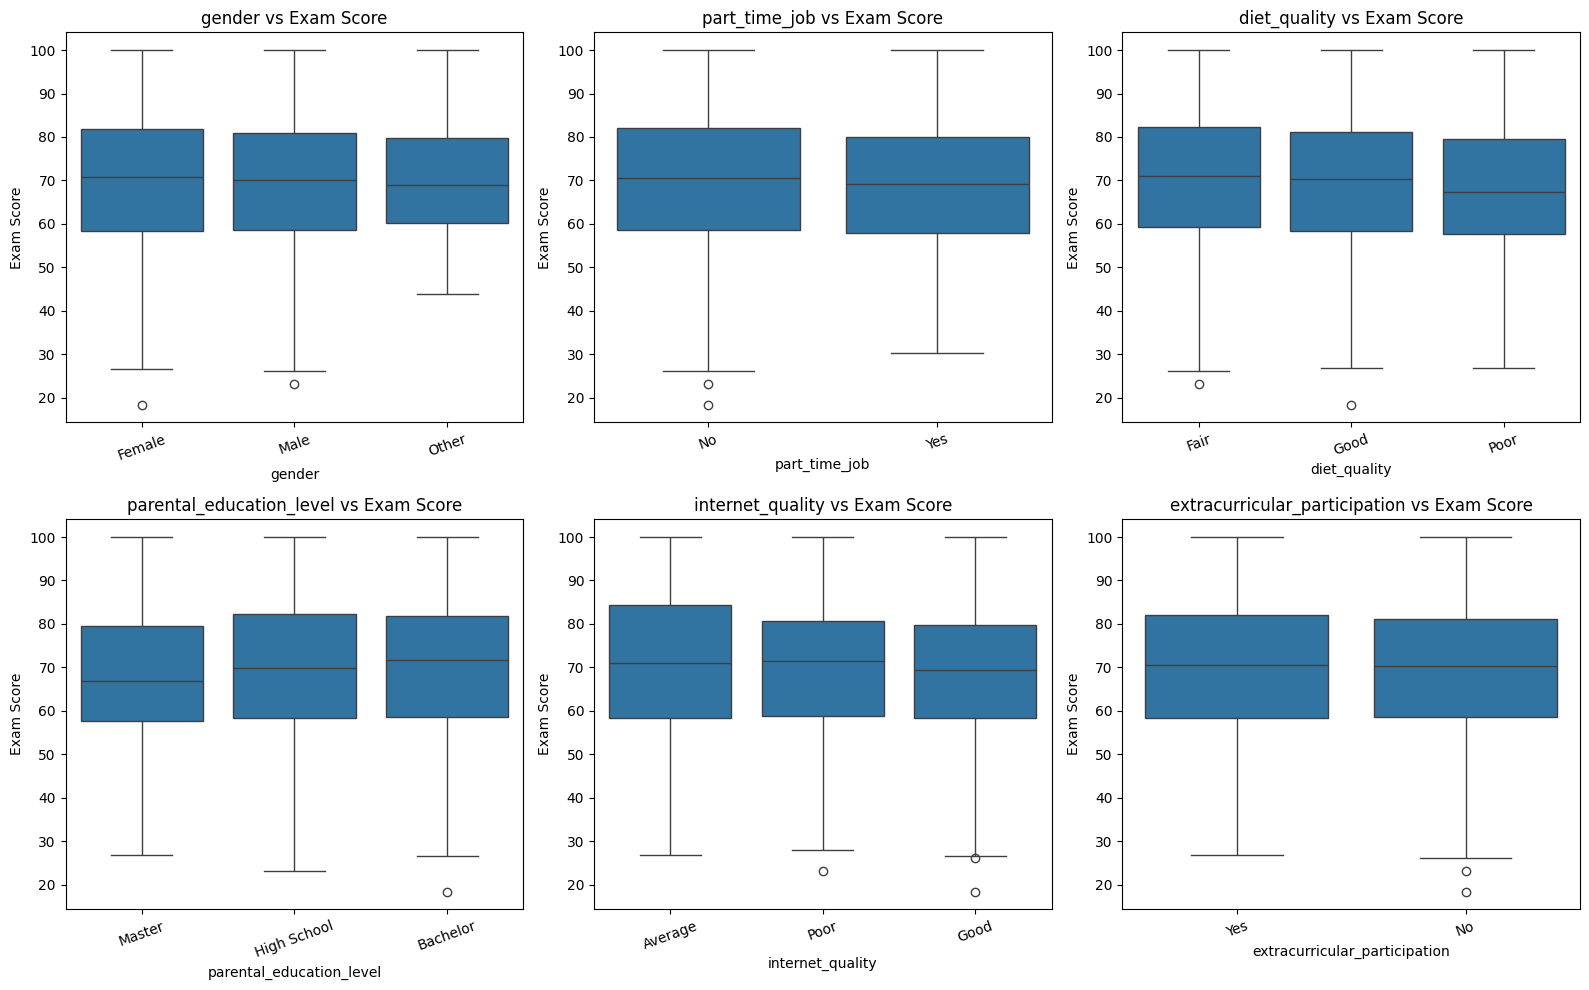

In [128]:
# ============================================
# CATEGORICAL FEATURES VS EXAM SCORE
# ============================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 10)
)

axes = axes.flatten()

for i, column in enumerate(categorical_features):

    sns.boxplot(
        data=df,
        x=column,
        y="exam_score",
        ax=axes[i]
    )

    axes[i].set_title(f"{column} vs Exam Score")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Exam Score")
    axes[i].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Correlation Analysis

Pearson correlation analysis is performed to examine the strength and direction of linear relationships between numerical variables and the target variable, `exam_score`.

Correlation analysis provides an initial understanding of which numerical variables may be associated with academic performance. However, correlation does not imply causation and cannot capture complex nonlinear relationships.

In [129]:
# Calculate the Pearson correlation of numerical features with exam score

target_correlations = (
    df[numerical_features + ["exam_score"]]
    .corr()["exam_score"]
    .drop("exam_score")
    .sort_values(ascending=False)
)

target_correlations

,exam_score
study_hours_per_day,0.825419
mental_health_rating,0.321523
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907
social_media_hours,-0.166733
netflix_hours,-0.171779


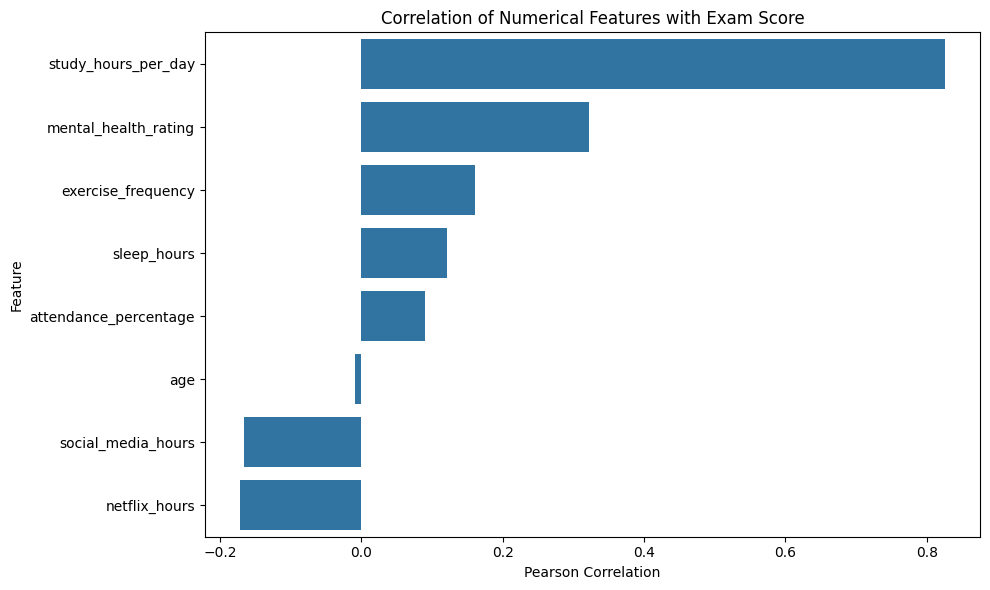

In [130]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=target_correlations.values,
    y=target_correlations.index
)

plt.title("Correlation of Numerical Features with Exam Score")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Multicollinearity Analysis

Multicollinearity occurs when predictor variables are strongly correlated with one another.

Variance Inflation Factor (VIF) is used as a diagnostic measure to identify potential multicollinearity among numerical predictors. This is particularly relevant for coefficient-based regression models because strong relationships between predictors can affect the stability and interpretability of model coefficients.

VIF is used as a diagnostic measure and is not treated as an automatic criterion for removing features.

In [131]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numerical predictor variables
vif_features = df[numerical_features].copy()

# Calculate VIF
vif_data = pd.DataFrame()

vif_data["Feature"] = vif_features.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        vif_features.values,
        i
    )
    for i in range(vif_features.shape[1])
]

vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
)

vif_data

,Feature,VIF
0,age,1.004321
2,social_media_hours,1.003940
1,study_hours_per_day,1.003660
4,attendance_percentage,1.003613
5,sleep_hours,1.003199
6,exercise_frequency,1.002675
7,mental_health_rating,1.002534
3,netflix_hours,1.001235


## Data Quality and Domain Validation

The numerical variables are examined for values that fall outside their expected domain ranges.

This analysis helps identify potentially invalid observations and ensures that the dataset is consistent with the expected meaning and measurement range of each variable.

Extreme but valid observations are retained and are not removed solely because they appear unusual.

In [132]:
# Define expected domain ranges

domain_checks = {
    "age": (17, 24),
    "study_hours_per_day": (0, 24),
    "social_media_hours": (0, 24),
    "netflix_hours": (0, 24),
    "attendance_percentage": (0, 100),
    "sleep_hours": (0, 24),
    "exercise_frequency": (0, 7),
    "mental_health_rating": (1, 10),
    "exam_score": (0, 100)
}

domain_results = []

for feature, (lower, upper) in domain_checks.items():

    invalid_count = (
        (df[feature] < lower) |
        (df[feature] > upper)
    ).sum()

    domain_results.append({
        "Feature": feature,
        "Expected Minimum": lower,
        "Expected Maximum": upper,
        "Invalid Values": invalid_count
    })

domain_results = pd.DataFrame(domain_results)

domain_results

,Feature,Expected Minimum,Expected Maximum,Invalid Values
0,age,17,24,0
1,study_hours_per_day,0,24,0
2,social_media_hours,0,24,0
3,netflix_hours,0,24,0
4,attendance_percentage,0,100,0
5,sleep_hours,0,24,0
6,exercise_frequency,0,7,0
7,mental_health_rating,1,10,0
8,exam_score,0,100,0


## Daily Activity Consistency

A consistency check is performed by summing the reported hours spent on studying, social media, Netflix, and sleeping.

The purpose is to identify records where the reported activities exceed the total number of hours available in a day.

In [133]:
# Calculate total reported daily hours

df["tracked_daily_hours"] = (
    df["study_hours_per_day"]
    + df["social_media_hours"]
    + df["netflix_hours"]
    + df["sleep_hours"]
)

print(
    "Maximum tracked daily hours:",
    df["tracked_daily_hours"].max()
)

print(
    "Records exceeding 24 hours:",
    (df["tracked_daily_hours"] > 24).sum()
)

Maximum tracked daily hours: 21.5
Records exceeding 24 hours: 0


In [134]:
df.drop(columns=["tracked_daily_hours"], inplace=True)

## Exploratory Data Analysis Summary

The exploratory analysis provided an overview of the dataset structure, distributions, relationships, and data quality.

The numerical feature analysis showed a strong positive linear association between study hours per day and exam score, while mental health rating showed a moderate positive association. Exercise frequency, sleep hours, and attendance percentage showed weaker positive associations. Social media hours and Netflix hours showed weak negative associations, whereas age showed almost no linear association with exam score.

The categorical feature analysis indicated variations in examination score distributions across different student groups. These differences are treated as exploratory associations rather than causal relationships.

Multicollinearity analysis using Variance Inflation Factor showed VIF values close to 1 for all numerical predictors, indicating negligible multicollinearity.

Domain validation detected no values outside the predefined valid ranges. The daily activity consistency check also found no records exceeding 24 reported hours, with the maximum tracked daily time being 21.5 hours.

Overall, the dataset passed the initial data-quality and exploratory checks and is suitable for the subsequent machine learning pipeline.

## Train-Test Split

The dataset is divided into training and testing subsets before model development.

The training set is used to learn model parameters, while the testing set is reserved for final evaluation on unseen observations.

The target variable is `exam_score`. The `student_id` column is excluded because it is an identifier and does not represent a meaningful predictive characteristic.

An 80:20 train-test split is used with a fixed random state to ensure reproducibility.

In [135]:
from sklearn.model_selection import train_test_split

# Separate predictors and target
X = df.drop(columns=["exam_score", "student_id"])
y = df["exam_score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training set shape: (800, 14)
Testing set shape: (200, 14)

Training target shape: (800,)
Testing target shape: (200,)


## Target Distribution Across Train and Test Sets

The distribution of the target variable is compared between the training and testing subsets to verify that the split has not produced a substantially different target distribution.

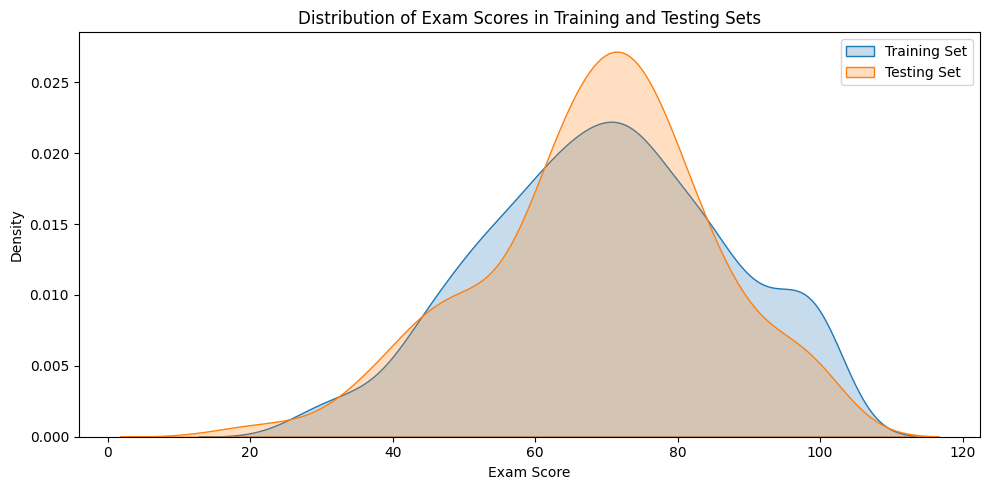

In [136]:
plt.figure(figsize=(10, 5))

sns.kdeplot(
    y_train,
    label="Training Set",
    fill=True
)

sns.kdeplot(
    y_test,
    label="Testing Set",
    fill=True
)

plt.title("Distribution of Exam Scores in Training and Testing Sets")
plt.xlabel("Exam Score")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

## Feature Type Identification

The predictor variables are separated into numerical and categorical features.

Numerical features will be processed using numerical preprocessing techniques, while categorical features will be encoded before being supplied to machine learning models.

In [137]:
# Identify numerical and categorical features

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']

Categorical features:
['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


## Preprocessing Pipeline

A unified preprocessing pipeline is developed to transform numerical and categorical predictors before machine learning.

Numerical features are processed using median imputation followed by standardization. Categorical features are processed using most-frequent imputation followed by one-hot encoding.

The preprocessing steps are integrated using a `ColumnTransformer` and are applied within a machine learning pipeline. This ensures that preprocessing parameters are learned only from the training data and prevents information leakage from the test set.

In [138]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical preprocessing
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Baseline Model: Linear Regression

Linear Regression is used as the initial baseline model for predicting examination scores.

The model assumes a linear relationship between the input variables and the target variable. Establishing a simple baseline provides a reference point for evaluating whether more complex machine learning algorithms provide meaningful improvements in predictive performance.

In [139]:
from sklearn.linear_model import LinearRegression

# Create the complete baseline pipeline
linear_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train the model
linear_regression_pipeline.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Model Evaluation Metrics

The models are evaluated using multiple regression metrics to provide a comprehensive assessment of predictive performance.

The evaluation includes Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R-squared (R²), and Mean Absolute Percentage Error (MAPE).

MAE measures the average absolute prediction error and is easy to interpret in the original target scale.

RMSE gives greater weight to larger prediction errors and is therefore useful for identifying models that produce substantial prediction mistakes.

R² measures the proportion of variance in the target variable explained by the model.

MAPE expresses prediction error as a percentage and provides an intuitive relative error measure. Since MAPE can become unstable when actual target values are close to zero, it is interpreted alongside MAE and RMSE rather than used alone.

In [140]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
import numpy as np

# Generate predictions on the unseen test set
y_pred = linear_regression_pipeline.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

mape = mean_absolute_percentage_error(
    y_test,
    y_pred
) * 100

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 4.1923
RMSE : 5.1510
R²   : 0.8965
MAPE : 6.92%


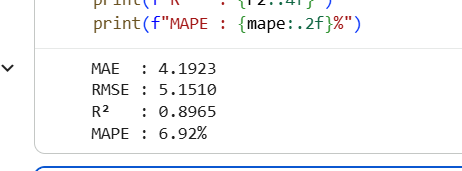

## Baseline Model Results

The performance of the baseline Linear Regression model is recorded as a reference for comparison with subsequent machine learning models.

In [141]:
# Store baseline model performance

results = []

results.append({
    "Model": "Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "MAPE": mape
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,4.192343,5.150974,0.896531,6.918658


## Ridge Regression

Ridge Regression extends ordinary linear regression by introducing L2 regularization.

The regularization term penalizes large model coefficients and can improve model stability and generalization, particularly when predictors contain redundant information or when the feature space becomes larger after categorical encoding.

Ridge Regression is evaluated against the Linear Regression baseline to determine whether regularization improves predictive performance.

In [142]:
from sklearn.linear_model import Ridge

# Create Ridge Regression pipeline
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

# Train Ridge Regression
ridge_pipeline.fit(X_train, y_train)

# Predictions
ridge_pred = ridge_pipeline.predict(X_test)

# Evaluation
ridge_mae = mean_absolute_error(y_test, ridge_pred)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_pred)
)

ridge_r2 = r2_score(y_test, ridge_pred)

ridge_mape = mean_absolute_percentage_error(
    y_test,
    ridge_pred
) * 100

print(f"MAE  : {ridge_mae:.4f}")
print(f"RMSE : {ridge_rmse:.4f}")
print(f"R²   : {ridge_r2:.4f}")
print(f"MAPE : {ridge_mape:.2f}%")

MAE  : 4.1926
RMSE : 5.1521
R²   : 0.8965
MAPE : 6.92%


In [143]:
results.append({
    "Model": "Ridge Regression",
    "MAE": ridge_mae,
    "RMSE": ridge_rmse,
    "R2": ridge_r2,
    "MAPE": ridge_mape
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,4.192343,5.150974,0.896531,6.918658
1,Ridge Regression,4.192586,5.152090,0.896486,6.923301


## Lasso Regression

Lasso Regression extends linear regression by introducing L1 regularization.

The L1 penalty can shrink some coefficients exactly to zero, providing an embedded form of feature selection. This makes Lasso useful for investigating whether a simpler subset of predictors can provide comparable predictive performance.

Lasso is compared with Linear Regression and Ridge Regression to evaluate the effect of L1 regularization on student performance prediction.

In [144]:
from sklearn.linear_model import Lasso

# Create Lasso Regression pipeline
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=0.01, max_iter=10000))
    ]
)

# Train Lasso Regression
lasso_pipeline.fit(X_train, y_train)

# Predictions
lasso_pred = lasso_pipeline.predict(X_test)

# Evaluation
lasso_mae = mean_absolute_error(y_test, lasso_pred)

lasso_rmse = np.sqrt(
    mean_squared_error(y_test, lasso_pred)
)

lasso_r2 = r2_score(y_test, lasso_pred)

lasso_mape = mean_absolute_percentage_error(
    y_test,
    lasso_pred
) * 100

print(f"MAE  : {lasso_mae:.4f}")
print(f"RMSE : {lasso_rmse:.4f}")
print(f"R²   : {lasso_r2:.4f}")
print(f"MAPE : {lasso_mape:.2f}%")

MAE  : 4.1867
RMSE : 5.1465
R²   : 0.8967
MAPE : 6.92%


In [145]:
results.append({
    "Model": "Lasso Regression",
    "MAE": lasso_mae,
    "RMSE": lasso_rmse,
    "R2": lasso_r2,
    "MAPE": lasso_mape
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,4.192343,5.150974,0.896531,6.918658
1,Ridge Regression,4.192586,5.152090,0.896486,6.923301
2,Lasso Regression,4.186662,5.146546,0.896709,6.915681


## Decision Tree Regression

Decision Tree Regression is introduced to evaluate whether nonlinear relationships and feature interactions can improve student performance prediction beyond linear models.

A decision tree recursively partitions the feature space into regions and predicts the target using the observations within each region.

Unlike linear regression models, decision trees can model nonlinear relationships and do not require feature scaling. However, unrestricted trees can overfit the training data, so tree complexity will be controlled and later optimized through hyperparameter tuning.

In [146]:
from sklearn.tree import DecisionTreeRegressor

# Create Decision Tree pipeline
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                random_state=42,
                max_depth=6
            )
        )
    ]
)

# Train the model
decision_tree_pipeline.fit(X_train, y_train)

# Predictions
tree_pred = decision_tree_pipeline.predict(X_test)

# Evaluation
tree_mae = mean_absolute_error(y_test, tree_pred)

tree_rmse = np.sqrt(
    mean_squared_error(y_test, tree_pred)
)

tree_r2 = r2_score(y_test, tree_pred)

tree_mape = mean_absolute_percentage_error(
    y_test,
    tree_pred
) * 100

print(f"MAE  : {tree_mae:.4f}")
print(f"RMSE : {tree_rmse:.4f}")
print(f"R²   : {tree_r2:.4f}")
print(f"MAPE : {tree_mape:.2f}%")

MAE  : 7.1448
RMSE : 9.1393
R²   : 0.6743
MAPE : 11.72%


In [147]:
results.append({
    "Model": "Decision Tree",
    "MAE": tree_mae,
    "RMSE": tree_rmse,
    "R2": tree_r2,
    "MAPE": tree_mape
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,4.192343,5.150974,0.896531,6.918658
1,Ridge Regression,4.192586,5.152090,0.896486,6.923301
2,Lasso Regression,4.186662,5.146546,0.896709,6.915681
3,Decision Tree,7.144834,9.139331,0.674267,11.715605


## Random Forest Regression

Random Forest Regression is introduced as an ensemble extension of the decision tree approach.

Instead of relying on a single decision tree, Random Forest constructs multiple trees using randomized samples and feature subsets, and combines their predictions.

This approach can reduce the variance of an individual decision tree and capture nonlinear relationships and feature interactions. Random Forest is therefore evaluated to determine whether ensemble learning provides better predictive performance than a single decision tree and the linear baselines.

In [148]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest pipeline
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
random_forest_pipeline.fit(X_train, y_train)

# Predictions
rf_pred = random_forest_pipeline.predict(X_test)

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

rf_mape = mean_absolute_percentage_error(
    y_test,
    rf_pred
) * 100

print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")
print(f"MAPE : {rf_mape:.2f}%")

MAE  : 4.9894
RMSE : 6.2192
R²   : 0.8492
MAPE : 8.32%


In [149]:
results.append({
    "Model": "Random Forest",
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "R2": rf_r2,
    "MAPE": rf_mape
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,4.192343,5.150974,0.896531,6.918658
1,Ridge Regression,4.192586,5.152090,0.896486,6.923301
2,Lasso Regression,4.186662,5.146546,0.896709,6.915681
3,Decision Tree,7.144834,9.139331,0.674267,11.715605
4,Random Forest,4.989401,6.219202,0.849165,8.322967


## Gradient Boosting Regression

Gradient Boosting Regression is evaluated as a sequential ensemble learning approach.

Unlike Random Forest, where trees are constructed independently, Gradient Boosting builds trees sequentially, with each new tree attempting to reduce the errors made by the existing ensemble.

This allows the model to capture nonlinear relationships and complex interactions between predictors. Its performance is compared with both linear and bagging-based ensemble models.

In [150]:
from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting pipeline
gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

# Train the model
gradient_boosting_pipeline.fit(X_train, y_train)

# Predictions
gb_pred = gradient_boosting_pipeline.predict(X_test)

# Evaluation
gb_mae = mean_absolute_error(y_test, gb_pred)

gb_rmse = np.sqrt(
    mean_squared_error(y_test, gb_pred)
)

gb_r2 = r2_score(y_test, gb_pred)

gb_mape = mean_absolute_percentage_error(
    y_test,
    gb_pred
) * 100

print(f"MAE  : {gb_mae:.4f}")
print(f"RMSE : {gb_rmse:.4f}")
print(f"R²   : {gb_r2:.4f}")
print(f"MAPE : {gb_mape:.2f}%")

MAE  : 4.6451
RMSE : 5.6119
R²   : 0.8772
MAPE : 7.61%


In [151]:
results.append({
    "Model": "Gradient Boosting",
    "MAE": gb_mae,
    "RMSE": gb_rmse,
    "R2": gb_r2,
    "MAPE": gb_mape
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,4.192343,5.150974,0.896531,6.918658
1,Ridge Regression,4.192586,5.152090,0.896486,6.923301
2,Lasso Regression,4.186662,5.146546,0.896709,6.915681
3,Decision Tree,7.144834,9.139331,0.674267,11.715605
4,Random Forest,4.989401,6.219202,0.849165,8.322967
5,Gradient Boosting,4.645143,5.611877,0.877186,7.611573


## Extra Trees Regression

Extra Trees Regression is evaluated as a highly randomized tree ensemble.

Similar to Random Forest, Extra Trees combines predictions from multiple decision trees. However, it introduces additional randomness when selecting split thresholds during tree construction.

This additional randomization can reduce correlation between individual trees and may improve generalization. The model is therefore compared with Random Forest and Gradient Boosting to examine whether a more randomized ensemble can capture useful nonlinear patterns in the student performance data.

In [152]:
from sklearn.ensemble import ExtraTreesRegressor

# Create Extra Trees pipeline
extra_trees_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
extra_trees_pipeline.fit(X_train, y_train)

# Predictions
et_pred = extra_trees_pipeline.predict(X_test)

# Evaluation
et_mae = mean_absolute_error(y_test, et_pred)

et_rmse = np.sqrt(
    mean_squared_error(y_test, et_pred)
)

et_r2 = r2_score(y_test, et_pred)

et_mape = mean_absolute_percentage_error(
    y_test,
    et_pred
) * 100

print(f"MAE  : {et_mae:.4f}")
print(f"RMSE : {et_rmse:.4f}")
print(f"R²   : {et_r2:.4f}")
print(f"MAPE : {et_mape:.2f}%")

MAE  : 5.0425
RMSE : 6.2382
R²   : 0.8482
MAPE : 8.41%


In [153]:
results.append({
    "Model": "Extra Trees",
    "MAE": et_mae,
    "RMSE": et_rmse,
    "R2": et_r2,
    "MAPE": et_mape
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,4.192343,5.150974,0.896531,6.918658
1,Ridge Regression,4.192586,5.152090,0.896486,6.923301
2,Lasso Regression,4.186662,5.146546,0.896709,6.915681
3,Decision Tree,7.144834,9.139331,0.674267,11.715605
4,Random Forest,4.989401,6.219202,0.849165,8.322967
5,Gradient Boosting,4.645143,5.611877,0.877186,7.611573
6,Extra Trees,5.042482,6.238159,0.848244,8.407458


In [154]:
!pip install -q xgboost

In [155]:
from xgboost import XGBRegressor

print("XGBoost imported successfully.")

XGBoost imported successfully.


## XGBoost Regression

XGBoost (Extreme Gradient Boosting) is evaluated as an advanced gradient boosting model for student performance prediction.

The model builds decision trees sequentially and optimizes the prediction error using gradient-based boosting. It also incorporates regularization mechanisms to control model complexity.

XGBoost is included to examine whether an advanced boosting approach can capture nonlinear relationships and feature interactions that are not fully captured by the linear baseline models.

The initial configuration is used only for baseline comparison. Hyperparameter optimization will be performed later using cross-validation.

In [156]:
from xgboost import XGBRegressor

# Create XGBoost pipeline
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0,
                reg_lambda=1,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
xgb_pipeline.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_pipeline.predict(X_test)

# Evaluation
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

xgb_r2 = r2_score(y_test, xgb_pred)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_pred
) * 100

print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")
print(f"MAPE : {xgb_mape:.2f}%")

MAE  : 4.4879
RMSE : 5.4968
R²   : 0.8822
MAPE : 7.26%


In [157]:
results.append({
    "Model": "XGBoost",
    "MAE": xgb_mae,
    "RMSE": xgb_rmse,
    "R2": xgb_r2,
    "MAPE": xgb_mape
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,4.192343,5.150974,0.896531,6.918658
1,Ridge Regression,4.192586,5.152090,0.896486,6.923301
2,Lasso Regression,4.186662,5.146546,0.896709,6.915681
3,Decision Tree,7.144834,9.139331,0.674267,11.715605
4,Random Forest,4.989401,6.219202,0.849165,8.322967
5,Gradient Boosting,4.645143,5.611877,0.877186,7.611573
6,Extra Trees,5.042482,6.238159,0.848244,8.407458
7,XGBoost,4.487944,5.496782,0.882172,7.260264


## Initial Model Benchmarking

The initial benchmark compares eight regression algorithms using the same training-testing split and evaluation metrics.

The purpose of this stage is to understand the relative behavior of linear, regularized, tree-based, bagging, and boosting approaches before hyperparameter optimization.

These results are considered preliminary because they are based on a single hold-out test split. Final model assessment will incorporate cross-validation and hyperparameter optimization.

In [158]:
# Display model comparison
results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

,Model,MAE,RMSE,R2,MAPE
0,Lasso Regression,4.186662,5.146546,0.896709,6.915681
1,Linear Regression,4.192343,5.150974,0.896531,6.918658
2,Ridge Regression,4.192586,5.152090,0.896486,6.923301
3,XGBoost,4.487944,5.496782,0.882172,7.260264
4,Gradient Boosting,4.645143,5.611877,0.877186,7.611573
5,Random Forest,4.989401,6.219202,0.849165,8.322967
6,Extra Trees,5.042482,6.238159,0.848244,8.407458
7,Decision Tree,7.144834,9.139331,0.674267,11.715605


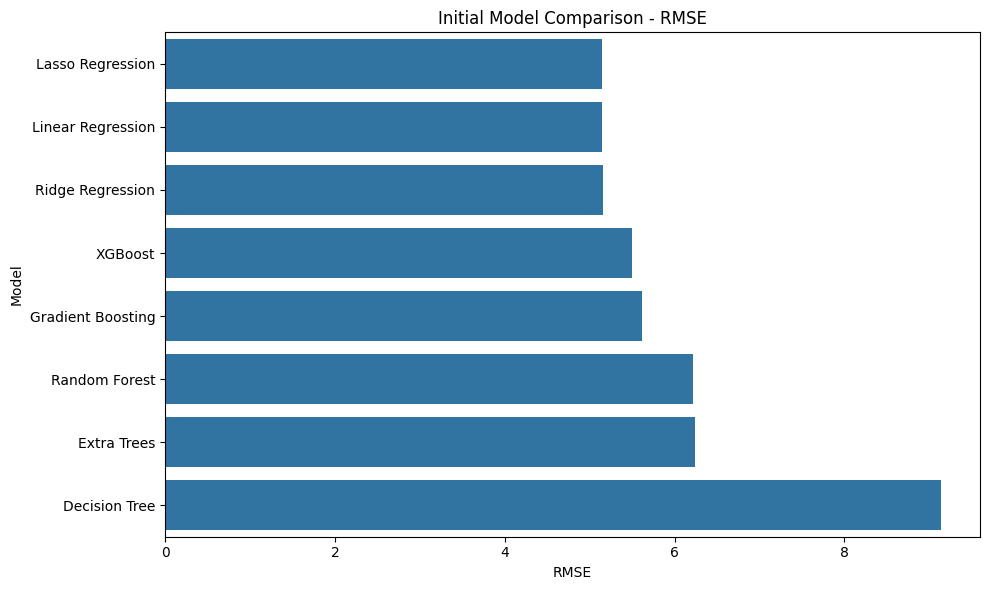

In [159]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df.sort_values("RMSE"),
    x="RMSE",
    y="Model"
)

plt.title("Initial Model Comparison - RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

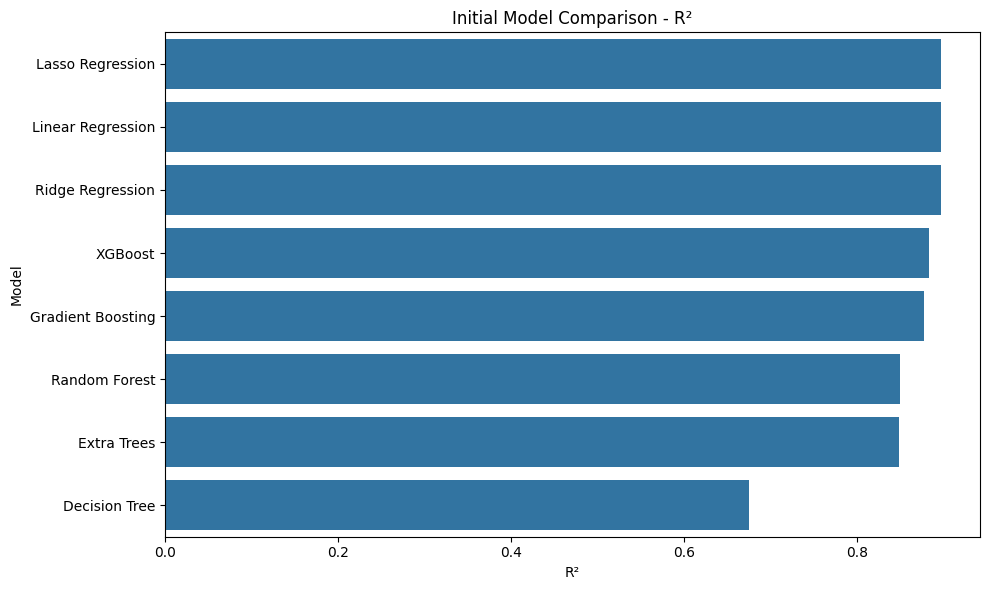

In [160]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df.sort_values("R2", ascending=False),
    x="R2",
    y="Model"
)

plt.title("Initial Model Comparison - R²")
plt.xlabel("R²")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

## Cross-Validation

Five-fold cross-validation is used to obtain a more robust estimate of model performance.

The training data is divided into five folds. In each iteration, four folds are used for training and the remaining fold is used for validation. This process is repeated until every fold has been used for validation.

Mean and standard deviation of the cross-validation scores are reported to assess both predictive performance and stability.

Cross-validation is performed only on the training data so that the independent test set remains untouched for final evaluation.

In [161]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

In [162]:
models = {
    "Linear Regression": linear_regression_pipeline,
    "Ridge Regression": ridge_pipeline,
    "Lasso Regression": lasso_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline,
    "Extra Trees": extra_trees_pipeline,
    "XGBoost": xgb_pipeline
}

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "MAE Mean": -scores["test_MAE"].mean(),
        "MAE Std": scores["test_MAE"].std(),
        "RMSE Mean": -scores["test_RMSE"].mean(),
        "RMSE Std": scores["test_RMSE"].std(),
        "R2 Mean": scores["test_R2"].mean(),
        "R2 Std": scores["test_R2"].std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    by="RMSE Mean",
    ascending=True
).reset_index(drop=True)

,Model,MAE Mean,MAE Std,RMSE Mean,RMSE Std,R2 Mean,R2 Std
0,Lasso Regression,4.341698,0.380776,5.493630,0.476684,0.895327,0.016714
1,Ridge Regression,4.351494,0.384301,5.507146,0.482850,0.894801,0.016956
2,Linear Regression,4.352921,0.384043,5.508992,0.483491,0.894731,0.016972
3,XGBoost,4.650695,0.403379,5.828993,0.388337,0.882417,0.014354
4,Gradient Boosting,4.757363,0.413742,5.967314,0.409668,0.876812,0.015147
5,Random Forest,5.301913,0.380237,6.604255,0.402846,0.848884,0.019099
6,Extra Trees,5.397739,0.417764,6.717018,0.455735,0.843664,0.021211
7,Decision Tree,7.044956,0.268598,8.932275,0.147116,0.723250,0.029220


## Hyperparameter Optimization

Hyperparameter optimization is performed to determine whether the performance of the baseline models can be improved through systematic parameter selection.

Lasso and Ridge regression are tuned first because they achieved the strongest cross-validation performance in the initial benchmark.

The optimization is performed using cross-validation on the training data. The independent test data is not used during hyperparameter selection.

In [163]:
from sklearn.model_selection import GridSearchCV

lasso_param_grid = {
    "model__alpha": [
        0.0001,
        0.001,
        0.01,
        0.05,
        0.1,
        0.5,
        1.0,
        2.0,
        5.0,
        10.0
    ]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)

lasso_grid.fit(X_train, y_train)

print("Best Parameters:")
print(lasso_grid.best_params_)

print("\nBest CV RMSE:")
print(-lasso_grid.best_score_)

Best Parameters:
{'model__alpha': 0.1}

Best CV RMSE:
5.430136114391535


In [164]:
lasso_cv_results = pd.DataFrame(
    lasso_grid.cv_results_
)

lasso_cv_results[
    [
        "param_model__alpha",
        "mean_test_score",
        "std_test_score"
    ]
].sort_values(
    by="mean_test_score",
    ascending=False
)

,param_model__alpha,mean_test_score,std_test_score
4,0.1000,-5.430136,0.454576
3,0.0500,-5.449427,0.459908
2,0.0100,-5.493630,0.476684
1,0.0010,-5.507446,0.482784
0,0.0001,-5.508828,0.483412
5,0.5000,-5.563473,0.467154
6,1.0000,-6.008698,0.485738
7,2.0000,-7.403471,0.509997
8,5.0000,-10.562653,0.666999
9,10.0000,-13.873808,0.721520


## Ridge Regression Hyperparameter Optimization

Ridge regression is optimized by searching for an appropriate regularization strength.

The alpha parameter controls the amount of L2 regularization. A small alpha allows the model to retain more flexibility, while a very large alpha can excessively constrain the coefficients and lead to underfitting.

Five-fold cross-validation is used to select the value that minimizes validation RMSE.

In [165]:
ridge_param_grid = {
    "model__alpha": [
        0.0001,
        0.001,
        0.01,
        0.05,
        0.1,
        0.5,
        1.0,
        2.0,
        5.0,
        10.0
    ]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)

ridge_grid.fit(X_train, y_train)

print("Best Parameters:")
print(ridge_grid.best_params_)

print("\nBest CV RMSE:")
print(-ridge_grid.best_score_)

Best Parameters:
{'model__alpha': 10.0}

Best CV RMSE:
5.4984501753784825


In [166]:
ridge_cv_results = pd.DataFrame(
    ridge_grid.cv_results_
)

ridge_cv_results[
    [
        "param_model__alpha",
        "mean_test_score",
        "std_test_score"
    ]
].sort_values(
    by="mean_test_score",
    ascending=False
)

,param_model__alpha,mean_test_score,std_test_score
9,10.0000,-5.498450,0.478152
8,5.0000,-5.501603,0.480554
7,2.0000,-5.505490,0.482238
6,1.0000,-5.507146,0.482850
5,0.5000,-5.508045,0.483167
4,0.1000,-5.508799,0.483426
3,0.0500,-5.508895,0.483459
2,0.0100,-5.508973,0.483485
1,0.0010,-5.508990,0.483491
0,0.0001,-5.508992,0.483491


## XGBoost Hyperparameter Optimization

XGBoost contains several interacting hyperparameters that control model complexity, learning rate, sampling, and regularization.

Randomized search with five-fold cross-validation is used to explore the hyperparameter space efficiently.

The objective is to identify a configuration that improves validation RMSE while avoiding excessive model complexity and overfitting.

In [167]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_distributions = {
    "model__n_estimators": [100, 200, 300, 500, 700],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_distributions,
    n_iter=30,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

xgb_random.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_random.best_params_)

print("\nBest CV RMSE:")
print(-xgb_random.best_score_)

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}

Best CV RMSE:
5.734964929951834


In [168]:
xgb_cv_results = pd.DataFrame(
    xgb_random.cv_results_
)

xgb_cv_results[
    [
        "params",
        "mean_test_score",
        "std_test_score"
    ]
].sort_values(
    by="mean_test_score",
    ascending=False
).head(10)

,params,mean_test_score,std_test_score
27,"{'model__subsample': 0.8, 'model__n_estimators...",-5.734965,0.457390
4,"{'model__subsample': 0.9, 'model__n_estimators...",-5.803132,0.430687
0,"{'model__subsample': 0.9, 'model__n_estimators...",-5.836494,0.415376
26,"{'model__subsample': 0.8, 'model__n_estimators...",-5.847548,0.349051
24,"{'model__subsample': 1.0, 'model__n_estimators...",-5.893864,0.439820
20,"{'model__subsample': 0.8, 'model__n_estimators...",-5.950285,0.415168
28,"{'model__subsample': 1.0, 'model__n_estimators...",-5.954209,0.373304
7,"{'model__subsample': 0.7, 'model__n_estimators...",-6.046681,0.457426
17,"{'model__subsample': 1.0, 'model__n_estimators...",-6.054064,0.342380
25,"{'model__subsample': 0.8, 'model__n_estimators...",-6.068873,0.405346


## Feature Selection Using Mutual Information

Feature selection is performed to identify predictors that contain useful information about examination performance.

Mutual Information is used because it can capture both linear and nonlinear dependencies between features and the target variable.

The selected features will later be evaluated using the same cross-validation framework to determine whether reducing the feature space improves predictive performance or model generalization.

In [169]:
from sklearn.feature_selection import mutual_info_regression

# Encode the categorical variables using the existing preprocessor
X_train_transformed = preprocessor.fit_transform(X_train)

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Convert sparse matrix if necessary
if hasattr(X_train_transformed, "toarray"):
    X_train_mi = X_train_transformed.toarray()
else:
    X_train_mi = X_train_transformed

# Calculate mutual information
mi_scores = mutual_info_regression(
    X_train_mi,
    y_train,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": feature_names,
    "Mutual_Information": mi_scores
}).sort_values(
    "Mutual_Information",
    ascending=False
).reset_index(drop=True)

mi_results

,Feature,Mutual_Information
0,num__study_hours_per_day,0.596319
1,num__mental_health_rating,0.097967
2,num__sleep_hours,0.042843
3,num__exercise_frequency,0.031065
4,cat__parental_education_level_Bachelor,0.027501
5,num__netflix_hours,0.015854
6,cat__diet_quality_Good,0.013079
7,num__social_media_hours,0.011964
8,cat__gender_Female,0.011710
9,cat__diet_quality_Poor,0.008034


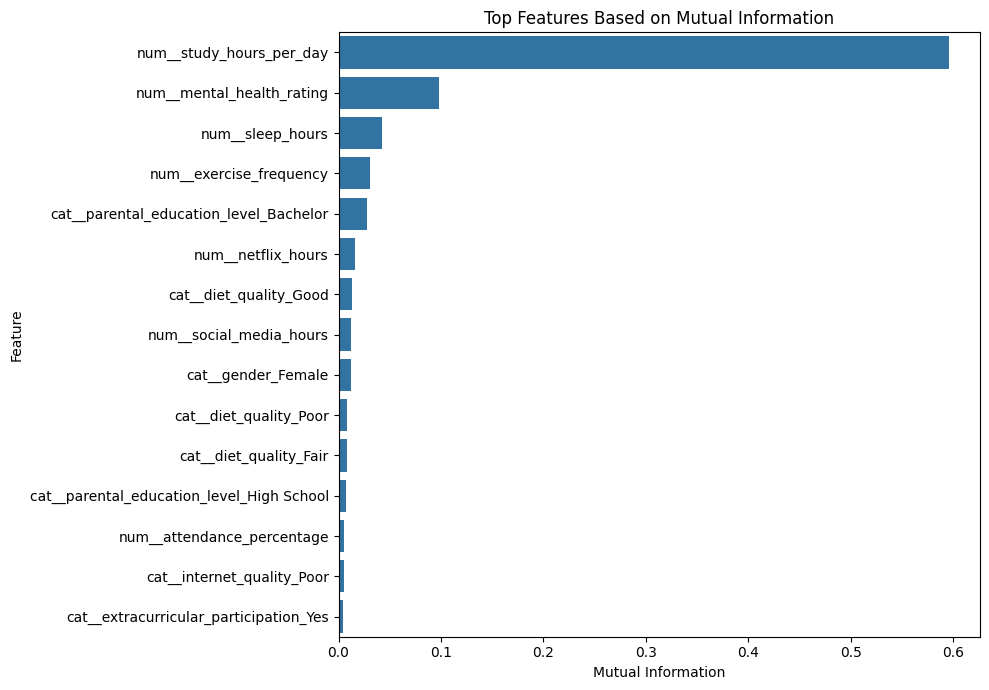

In [170]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=mi_results.head(15),
    x="Mutual_Information",
    y="Feature"
)

plt.title("Top Features Based on Mutual Information")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Cross-Validated Feature Selection

The previous mutual information analysis was used as an exploratory feature relevance analysis.

To avoid information leakage, feature selection is now incorporated directly into the machine learning pipeline. Mutual information is calculated independently within each cross-validation training fold, and only the selected features are passed to the regression model.

Different numbers of selected features are evaluated to determine whether a reduced feature space can maintain or improve predictive performance compared with using all available features.

In [171]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.model_selection import cross_validate

numeric_features = [
    "age",
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "attendance_percentage",
    "sleep_hours",
    "exercise_frequency",
    "mental_health_rating"
]

categorical_features = [
    "gender",
    "part_time_job",
    "diet_quality",
    "parental_education_level",
    "internet_quality",
    "extracurricular_participation"
]

dense_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [172]:
feature_selection_results = []

for k in [5, 8, 10, 15, 20, "all"]:

    selector = SelectKBest(
        score_func=mutual_info_regression,
        k=k
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", dense_preprocessor),
            ("selector", selector),
            (
                "model",
                Lasso(
                    alpha=0.1,
                    max_iter=10000
                )
            )
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=-1
    )

    feature_selection_results.append({
        "Selected Features": k,
        "MAE Mean": -scores["test_MAE"].mean(),
        "RMSE Mean": -scores["test_RMSE"].mean(),
        "R2 Mean": scores["test_R2"].mean(),
        "RMSE Std": scores["test_RMSE"].std()
    })

feature_selection_df = pd.DataFrame(
    feature_selection_results
)

feature_selection_df

,Selected Features,MAE Mean,RMSE Mean,R2 Mean,RMSE Std
0,5,5.528189,6.910253,0.831054,0.996522
1,8,5.207791,6.593153,0.847161,0.847384
2,10,5.105352,6.446977,0.853054,1.035491
3,15,4.542056,5.717819,0.885007,0.839606
4,20,4.633863,5.843296,0.880754,0.814800
5,all,4.304459,5.430038,0.897766,0.454727


## Feature Engineering

Feature engineering is performed to represent meaningful behavioral and academic relationships that may not be captured by the original variables independently.

The engineered features are designed from the educational context of the dataset rather than being generated arbitrarily. In particular, study effort, entertainment usage, time allocation, attendance, and psychological well-being are considered.

The engineered features will be evaluated through cross-validation to determine whether these representations improve student performance prediction.

In [173]:
df_fe = df.copy()

# Total entertainment time
df_fe["entertainment_hours"] = (
    df_fe["social_media_hours"] +
    df_fe["netflix_hours"]
)

# Study-to-entertainment ratio
df_fe["study_entertainment_ratio"] = (
    df_fe["study_hours_per_day"] /
    (df_fe["entertainment_hours"] + 1)
)

# Academic engagement indicator
df_fe["academic_engagement"] = (
    df_fe["study_hours_per_day"] *
    (df_fe["attendance_percentage"] / 100)
)

# Study and attendance interaction
df_fe["study_attendance_interaction"] = (
    df_fe["study_hours_per_day"] *
    df_fe["attendance_percentage"]
)

# Study and mental health interaction
df_fe["study_mental_health_interaction"] = (
    df_fe["study_hours_per_day"] *
    df_fe["mental_health_rating"]
)

# Sleep-adjusted study hours
df_fe["sleep_adjusted_study"] = (
    df_fe["study_hours_per_day"] *
    (df_fe["sleep_hours"] / 8)
)

# Overall daily tracked time
df_fe["tracked_daily_time"] = (
    df_fe["study_hours_per_day"] +
    df_fe["social_media_hours"] +
    df_fe["netflix_hours"] +
    df_fe["sleep_hours"]
)

df_fe.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,entertainment_hours,study_entertainment_ratio,academic_engagement,study_attendance_interaction,study_mental_health_interaction,sleep_adjusted_study,tracked_daily_time
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,2.3,0.000000,0.0000,0.00,0.0,0.0000,10.3
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0,5.1,1.131148,6.7137,671.37,55.2,3.9675,16.6
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,4.4,0.259259,1.3272,132.72,1.4,1.4000,13.8
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,4.9,0.169492,0.7100,71.00,1.0,1.1500,15.1
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4,4.9,0.847458,4.5450,454.50,5.0,3.0625,14.8


In [174]:
engineered_features = [
    "entertainment_hours",
    "study_entertainment_ratio",
    "academic_engagement",
    "study_attendance_interaction",
    "study_mental_health_interaction",
    "sleep_adjusted_study",
    "tracked_daily_time"
]

df_fe[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
entertainment_hours,1000.0,4.325200,1.599808,0.2,3.300000,4.400000,5.400000,10.1000
study_entertainment_ratio,1000.0,0.746880,0.446882,0.0,0.472377,0.660189,0.936170,4.5000
academic_engagement,1000.0,2.990382,1.309482,0.0,2.096925,2.956500,3.830925,7.5544
study_attendance_interaction,1000.0,299.038200,130.948182,0.0,209.692500,295.650000,383.092500,755.4400
study_mental_health_interaction,1000.0,19.289700,13.550590,0.0,8.000000,16.800000,28.000000,74.7000
sleep_adjusted_study,1000.0,2.864944,1.312214,0.0,1.924688,2.801250,3.682500,7.6725
tracked_daily_time,1000.0,14.345400,2.478395,6.8,12.600000,14.300000,16.025000,21.5000


In [175]:
engineered_corr = (
    df_fe[engineered_features + ["exam_score"]]
    .corr(numeric_only=True)["exam_score"]
    .drop("exam_score")
    .sort_values(ascending=False)
)

engineered_corr

,exam_score
academic_engagement,0.809390
study_attendance_interaction,0.809390
sleep_adjusted_study,0.801190
study_mental_health_interaction,0.722775
study_entertainment_ratio,0.707269
tracked_daily_time,0.396028
entertainment_hours,-0.237631


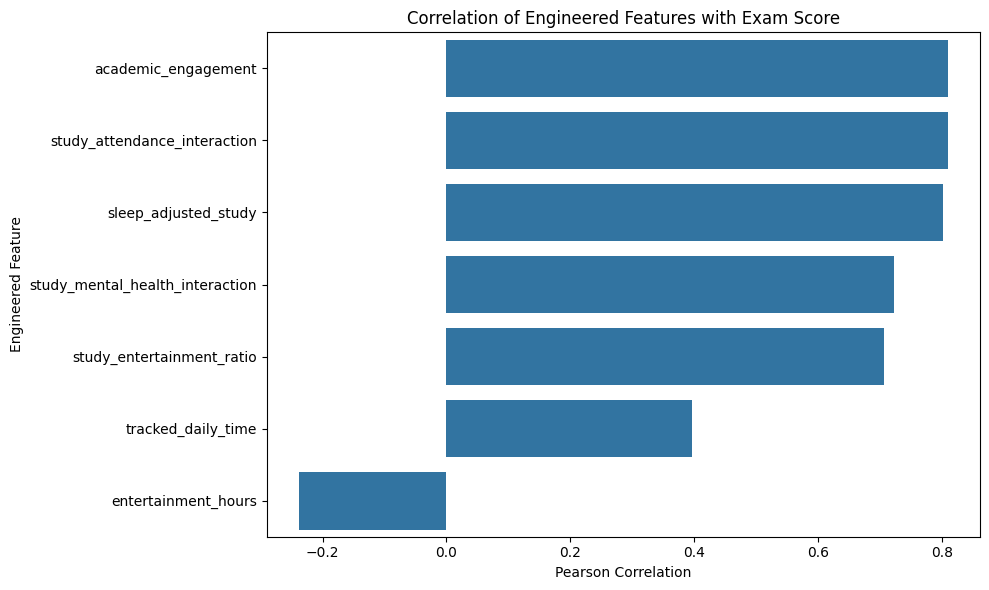

In [176]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=engineered_corr.values,
    y=engineered_corr.index
)

plt.title("Correlation of Engineered Features with Exam Score")
plt.xlabel("Pearson Correlation")
plt.ylabel("Engineered Feature")

plt.tight_layout()
plt.show()

## Feature Engineering Evaluation

The engineered features are evaluated using the same cross-validation procedure used for the baseline models.

The feature set includes domain-informed interaction and ratio features representing academic engagement, study-to-entertainment balance, sleep-adjusted study effort, mental-health-adjusted study effort, and total tracked daily activity.

Highly redundant engineered variables are excluded to avoid unnecessary duplication.

In [177]:
engineered_features_final = [
    "entertainment_hours",
    "study_entertainment_ratio",
    "academic_engagement",
    "study_mental_health_interaction",
    "sleep_adjusted_study",
    "tracked_daily_time"
]

# Create X with engineered features
X_fe = df_fe.drop(
    columns=["exam_score", "student_id"]
)

y_fe = df_fe["exam_score"]

X_fe.shape

(1000, 21)

In [178]:
numeric_features_fe = X_fe.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_fe = X_fe.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:", numeric_features_fe)
print("Categorical features:", categorical_features_fe)

Numeric features: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'entertainment_hours', 'study_entertainment_ratio', 'academic_engagement', 'study_attendance_interaction', 'study_mental_health_interaction', 'sleep_adjusted_study', 'tracked_daily_time']
Categorical features: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [179]:
# Remove the redundant interaction feature
X_fe = df_fe.drop(
    columns=[
        "exam_score",
        "student_id",
        "study_attendance_interaction"
    ]
)

y_fe = df_fe["exam_score"]

numeric_features_fe = X_fe.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_fe = X_fe.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:", numeric_features_fe)
print("Categorical features:", categorical_features_fe)

Numeric features: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'entertainment_hours', 'study_entertainment_ratio', 'academic_engagement', 'study_mental_health_interaction', 'sleep_adjusted_study', 'tracked_daily_time']
Categorical features: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [180]:
X_fe_train = X_fe.loc[X_train.index]
X_fe_test = X_fe.loc[X_test.index]

y_fe_train = y_fe.loc[y_train.index]
y_fe_test = y_fe.loc[y_test.index]

In [181]:
preprocessor_fe = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_fe
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_fe
        )
    ]
)

In [182]:
lasso_fe_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        (
            "model",
            Lasso(
                alpha=0.1,
                max_iter=10000
            )
        )
    ]
)

In [183]:
lasso_fe_scores = cross_validate(
    lasso_fe_pipeline,
    X_fe_train,
    y_fe_train,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)

lasso_fe_results = {
    "MAE": -lasso_fe_scores["test_MAE"].mean(),
    "RMSE": -lasso_fe_scores["test_RMSE"].mean(),
    "R2": lasso_fe_scores["test_R2"].mean(),
    "RMSE Std": lasso_fe_scores["test_RMSE"].std()
}

lasso_fe_results

{'MAE': np.float64(4.318060380550837),
 'RMSE': np.float64(5.44943808880161),
 'R2': np.float64(0.8971296357995151),
 'RMSE Std': np.float64(0.45245256513061444)}

In [184]:
xgb_fe_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=2,
                min_child_weight=3,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42
            )
        )
    ]
)

xgb_fe_scores = cross_validate(
    xgb_fe_pipeline,
    X_fe_train,
    y_fe_train,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)

xgb_fe_results = {
    "MAE": -xgb_fe_scores["test_MAE"].mean(),
    "RMSE": -xgb_fe_scores["test_RMSE"].mean(),
    "R2": xgb_fe_scores["test_R2"].mean(),
    "RMSE Std": xgb_fe_scores["test_RMSE"].std()
}

xgb_fe_results

{'MAE': np.float64(4.660524057388305),
 'RMSE': np.float64(5.770190488949157),
 'R2': np.float64(0.8846539778775883),
 'RMSE Std': np.float64(0.38313412620712706)}

In [185]:
lasso_fe_pipeline.fit(X_fe_train, y_fe_train)

feature_names_fe = (
    lasso_fe_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    lasso_fe_pipeline
    .named_steps["model"]
    .coef_
)

coef_df = pd.DataFrame({
    "Feature": feature_names_fe,
    "Coefficient": coefficients
})

coef_df["Absolute_Coefficient"] = (
    coef_df["Coefficient"].abs()
)

coef_df = coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coef_df.head(20)

,Feature,Coefficient,Absolute_Coefficient
1,num__study_hours_per_day,13.848911,13.848911
7,num__mental_health_rating,5.462858,5.462858
8,num__entertainment_hours,-3.535685,3.535685
6,num__exercise_frequency,2.551992,2.551992
5,num__sleep_hours,2.334007,2.334007
4,num__attendance_percentage,1.261365,1.261365
2,num__social_media_hours,-0.382600,0.382600
19,cat__diet_quality_Fair,0.333224,0.333224
9,num__study_entertainment_ratio,0.285737,0.285737
20,cat__diet_quality_Good,-0.151447,0.151447


## Redundancy-Aware Feature Selection

Several engineered features are mathematically derived from the same underlying variables.
This can introduce multicollinearity and redundant information into the feature space.

Lasso regression provides an additional mechanism for identifying redundant predictors by shrinking
their coefficients toward zero.

In this stage, highly redundant engineered features are examined and removed selectively.
The model is then retrained to determine whether a more compact feature set can maintain or
improve predictive performance.

In [186]:
# Identify redundant engineered features
redundant_features = [
    'academic_engagement',
    'study_attendance_interaction'
]

# Create reduced dataset
X_reduced = df.drop(
    columns=redundant_features + ['exam_score', 'student_id'],
    errors='ignore'
)

y_reduced = df['exam_score']

print("Original dataset shape:", df.shape)
print("Reduced feature count:", X_reduced.shape[1])
print("\nRemaining features:")
print(X_reduced.columns.tolist())

Original dataset shape: (1000, 16)
Reduced feature count: 14

Remaining features:
['age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']


## Reduced Feature Set Evaluation

The engineered feature analysis showed that several derived variables were strongly related
to their original components. To evaluate whether these engineered features provide
additional predictive value, a reduced feature set containing the original predictors is
evaluated using the same preprocessing and cross-validation strategy.

This experiment provides a controlled comparison between the original feature space and
the feature-engineered feature space.

In [187]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso
import numpy as np
import pandas as pd

# Identify feature types
numeric_features_reduced = X_reduced.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features_reduced = X_reduced.select_dtypes(
    include=['object']
).columns.tolist()

print("Numeric features:", numeric_features_reduced)
print("Categorical features:", categorical_features_reduced)

Numeric features: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
Categorical features: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [188]:
numeric_transformer_reduced = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_reduced = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_reduced = ColumnTransformer([
    ('num', numeric_transformer_reduced, numeric_features_reduced),
    ('cat', categorical_transformer_reduced, categorical_features_reduced)
])

In [189]:
lasso_reduced = Pipeline([
    ('preprocessor', preprocessor_reduced),
    ('model', Lasso(alpha=0.1, max_iter=10000))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    lasso_reduced,
    X_reduced,
    y_reduced,
    cv=cv,
    scoring={
        'MAE': 'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error',
        'R2': 'r2'
    },
    return_train_score=False
)

reduced_results = {
    'MAE': -scores['test_MAE'].mean(),
    'RMSE': -scores['test_RMSE'].mean(),
    'R2': scores['test_R2'].mean(),
    'RMSE Std': scores['test_RMSE'].std()
}

print("Reduced Feature Lasso Results")
print("--------------------------------")
for metric, value in reduced_results.items():
    print(f"{metric:<10}: {value:.4f}")

Reduced Feature Lasso Results
--------------------------------
MAE       : 4.2940
RMSE      : 5.3928
R2        : 0.8956
RMSE Std  : 0.3736


## Lasso Hyperparameter Optimization

The regularization strength (alpha) controls the amount of shrinkage applied by Lasso
regression. A very small alpha may retain unnecessary predictors, whereas a very large
alpha may remove useful information.

Therefore, GridSearchCV is used to identify the alpha value that provides the best
cross-validated prediction performance.

In [190]:
from sklearn.model_selection import GridSearchCV

alpha_grid = {
    'model__alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

lasso_grid = GridSearchCV(
    estimator=lasso_reduced,
    param_grid=alpha_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    return_train_score=False
)

lasso_grid.fit(X_reduced, y_reduced)

print("Best Alpha:", lasso_grid.best_params_['model__alpha'])
print("Best CV RMSE:", -lasso_grid.best_score_)

Best Alpha: 0.1
Best CV RMSE: 5.392818566742695


## Final Evaluation of Optimized Lasso Regression

After hyperparameter optimization, the best regularization strength was selected using
cross-validation. The optimized Lasso model is now evaluated on the unseen test set.

The test set is kept completely separate from model selection to provide an unbiased
estimate of generalization performance.

In [191]:
# Retrieve the optimized Lasso model
best_lasso = lasso_grid.best_estimator_

# Evaluate on the unseen test set
y_pred_lasso = best_lasso.predict(X_test)

lasso_test_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_test_rmse = mean_squared_error(y_test, y_pred_lasso) ** 0.5
lasso_test_r2 = r2_score(y_test, y_pred_lasso)
lasso_test_mape = mean_absolute_percentage_error(y_test, y_pred_lasso) * 100

print("Optimized Lasso - Test Set Performance")
print("---------------------------------------")
print(f"MAE  : {lasso_test_mae:.4f}")
print(f"RMSE : {lasso_test_rmse:.4f}")
print(f"R²   : {lasso_test_r2:.4f}")
print(f"MAPE : {lasso_test_mape:.2f}%")

Optimized Lasso - Test Set Performance
---------------------------------------
MAE  : 4.0620
RMSE : 5.0126
R²   : 0.9020
MAPE : 6.73%


## XGBoost Hyperparameter Optimization

XGBoost is evaluated as a nonlinear ensemble model to determine whether complex
interactions and nonlinear relationships among student behavioral, academic, and
demographic features can improve prediction beyond the regularized linear model.

Hyperparameter optimization is performed using cross-validation to control model
complexity and reduce the risk of overfitting.

In [192]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor_reduced),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [2, 3, 4, 5],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5, 7]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=False
)

xgb_search.fit(X_reduced, y_reduced)

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

print("\nBest CV RMSE:")
print(-xgb_search.best_score_)

Best XGBoost Parameters:
{'model__subsample': 0.9, 'model__n_estimators': 500, 'model__min_child_weight': 1, 'model__max_depth': 2, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}

Best CV RMSE:
5.5145922728190175


## Final Evaluation of Optimized XGBoost

The optimized XGBoost model is evaluated on the same unseen test set used for
the optimized Lasso model.

Using an identical test set allows a direct comparison between the linear
regularized model and the nonlinear ensemble model.

In [193]:
best_xgb = xgb_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

xgb_test_mae = mean_absolute_error(
    y_test,
    y_pred_xgb
)

xgb_test_rmse = mean_squared_error(
    y_test,
    y_pred_xgb
) ** 0.5

xgb_test_r2 = r2_score(
    y_test,
    y_pred_xgb
)

xgb_test_mape = (
    mean_absolute_percentage_error(
        y_test,
        y_pred_xgb
    ) * 100
)

print("Optimized XGBoost - Test Set Performance")
print("-----------------------------------------")
print(f"MAE  : {xgb_test_mae:.4f}")
print(f"RMSE : {xgb_test_rmse:.4f}")
print(f"R²   : {xgb_test_r2:.4f}")
print(f"MAPE : {xgb_test_mape:.2f}%")

Optimized XGBoost - Test Set Performance
-----------------------------------------
MAE  : 3.1881
RMSE : 3.9312
R²   : 0.9397
MAPE : 5.13%


## Residual and Prediction Error Analysis

Model performance is further investigated through residual analysis to understand
the types and magnitude of prediction errors.

Residuals are calculated as the difference between the observed examination score
and the predicted score. The analysis examines whether errors are randomly
distributed and identifies observations with comparatively large prediction errors.

This analysis provides additional evidence about the reliability and limitations
of the predictive model beyond aggregate evaluation metrics.

In [194]:
error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_xgb
})

error_analysis["Residual"] = (
    error_analysis["Actual"] -
    error_analysis["Predicted"]
)

error_analysis["Absolute_Error"] = (
    error_analysis["Residual"].abs()
)

error_analysis.head()

,Actual,Predicted,Residual,Absolute_Error
0,64.2,67.617271,-3.417271,3.417271
1,72.7,75.143448,-2.443448,2.443448
2,79.0,79.159035,-0.159035,0.159035
3,79.5,74.659142,4.840858,4.840858
4,58.2,57.826378,0.373622,0.373622


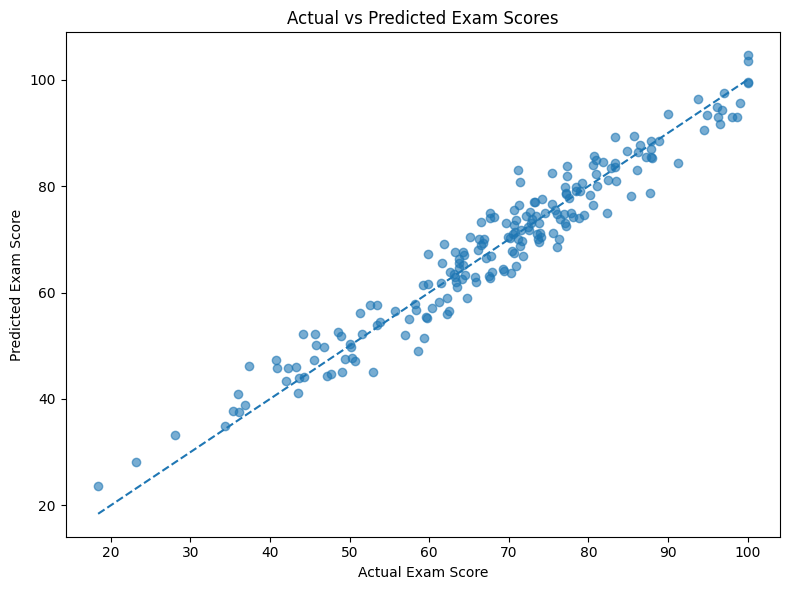

In [195]:
plt.figure(figsize=(8, 6))

plt.scatter(
    error_analysis["Actual"],
    error_analysis["Predicted"],
    alpha=0.6
)

plt.plot(
    [error_analysis["Actual"].min(),
     error_analysis["Actual"].max()],
    [error_analysis["Actual"].min(),
     error_analysis["Actual"].max()],
    linestyle="--"
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

plt.tight_layout()
plt.show()

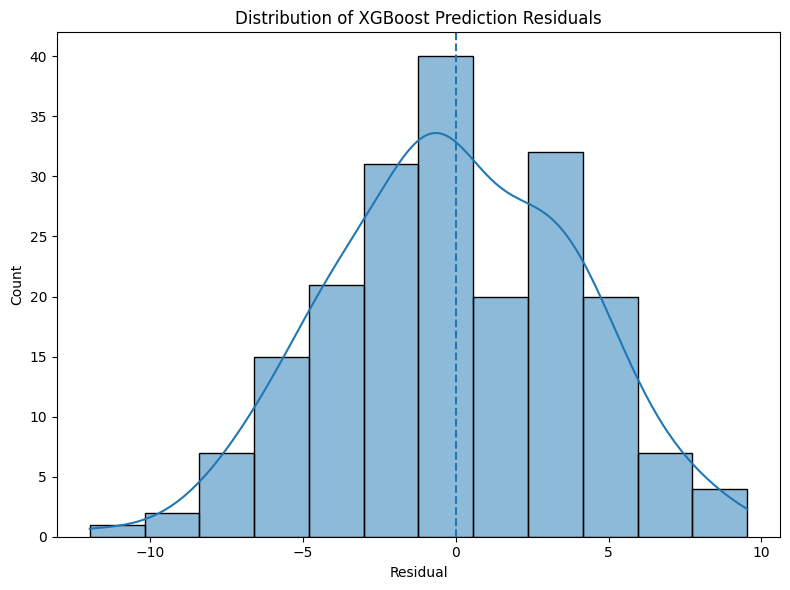

In [196]:
plt.figure(figsize=(8, 6))

sns.histplot(
    error_analysis["Residual"],
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.title("Distribution of XGBoost Prediction Residuals")

plt.tight_layout()
plt.show()

In [197]:
error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual,Predicted,Residual,Absolute_Error
121,71.1,83.059570,-11.959570,11.959570
91,58.6,49.068687,9.531313,9.531313
45,71.4,80.801392,-9.401392,9.401392
99,87.8,78.623810,9.176190,9.176190
65,37.4,46.200218,-8.800218,8.800218
19,59.4,51.366901,8.033099,8.033099
92,44.1,52.118587,-8.018587,8.018587
10,53.0,45.060848,7.939152,7.939152
133,76.1,68.535011,7.564989,7.564989
29,59.9,67.237068,-7.337068,7.337068


In [198]:
print("Available training variables:")
print([x for x in dir() if "train" in x.lower()])

Available training variables:
['X_fe_train', 'X_train', 'X_train_mi', 'X_train_transformed', 'X_train_transformed_xgb', 'train_test_split', 'y_fe_train', 'y_train']


In [199]:
print("X_train shape:", X_train.shape)
print("X_fe_train shape:", X_fe_train.shape)
print("X_train_mi shape:", X_train_mi.shape)
print("X_train_transformed shape:", X_train_transformed.shape)
print("y_train shape:", y_train.shape)

X_train shape: (800, 14)
X_fe_train shape: (800, 20)
X_train_mi shape: (800, 24)
X_train_transformed shape: (800, 24)
y_train shape: (800,)


In [200]:
# Train the optimized XGBoost model on the reduced feature set

best_xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=500,
        max_depth=2,
        learning_rate=0.05,
        min_child_weight=1,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42
    ))
])

best_xgb_model.fit(X_train, y_train)

print("Optimized XGBoost model fitted successfully.")

Optimized XGBoost model fitted successfully.


In [201]:
# Extract the fitted preprocessing and XGBoost model

xgb_model = best_xgb_model.named_steps["model"]
fitted_preprocessor = best_xgb_model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get XGBoost feature importance
importance = xgb_model.feature_importances_

# Create feature importance DataFrame
xgb_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)

# Display top features
xgb_feature_importance.head(15)

,Feature,Importance
1,num__study_hours_per_day,0.508771
7,num__mental_health_rating,0.161717
6,num__exercise_frequency,0.063241
2,num__social_media_hours,0.050916
3,num__netflix_hours,0.048177
5,num__sleep_hours,0.035522
4,num__attendance_percentage,0.016810
9,cat__gender_Male,0.010792
23,cat__extracurricular_participation_Yes,0.009588
20,cat__internet_quality_Good,0.009348


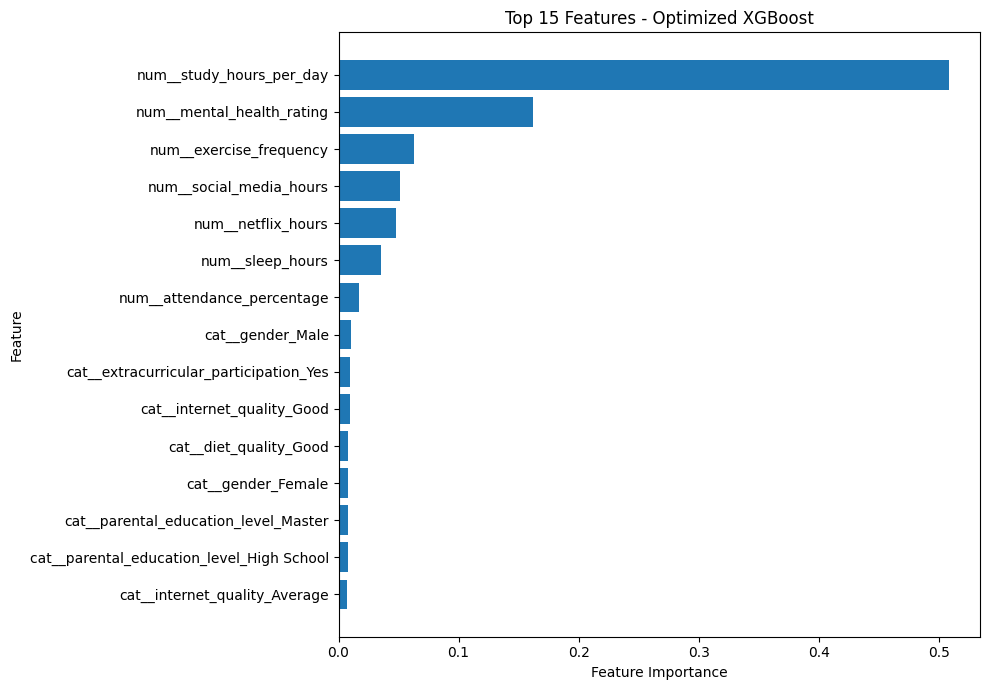

In [202]:
plt.figure(figsize=(10, 7))

top_features = xgb_feature_importance.head(15).sort_values(
    by="Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Optimized XGBoost")

plt.tight_layout()
plt.show()

In [203]:
!pip install -q shap

In [204]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP imported successfully.")

SHAP imported successfully.


In [205]:
# Get fitted preprocessing and XGBoost model
preprocessor_fitted = best_xgb_model.named_steps["preprocessor"]
xgb_fitted = best_xgb_model.named_steps["model"]

# Transform training data
X_train_transformed_xgb = preprocessor_fitted.transform(X_train)

print("Transformed shape:", X_train_transformed_xgb.shape)

Transformed shape: (800, 24)


In [206]:
feature_names = preprocessor_fitted.get_feature_names_out()

print("Number of features:", len(feature_names))
print("\nFeature names:")
print(feature_names)

Number of features: 24

Feature names:
['num__age' 'num__study_hours_per_day' 'num__social_media_hours'
 'num__netflix_hours' 'num__attendance_percentage' 'num__sleep_hours'
 'num__exercise_frequency' 'num__mental_health_rating'
 'cat__gender_Female' 'cat__gender_Male' 'cat__gender_Other'
 'cat__part_time_job_No' 'cat__part_time_job_Yes' 'cat__diet_quality_Fair'
 'cat__diet_quality_Good' 'cat__diet_quality_Poor'
 'cat__parental_education_level_Bachelor'
 'cat__parental_education_level_High School'
 'cat__parental_education_level_Master' 'cat__internet_quality_Average'
 'cat__internet_quality_Good' 'cat__internet_quality_Poor'
 'cat__extracurricular_participation_No'
 'cat__extracurricular_participation_Yes']


In [207]:
explainer = shap.TreeExplainer(xgb_fitted)

shap_values = explainer.shap_values(X_train_transformed_xgb)

print("SHAP analysis completed.")
print("SHAP shape:", shap_values.shape)

SHAP analysis completed.
SHAP shape: (800, 24)


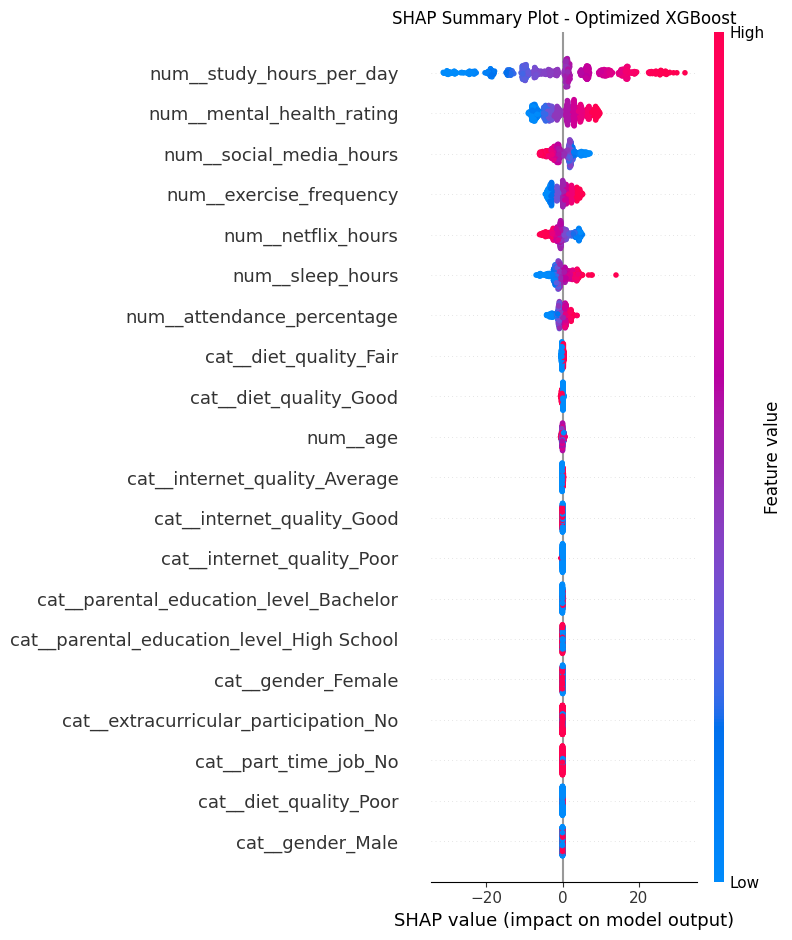

In [208]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_train_transformed_xgb,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Summary Plot - Optimized XGBoost")
plt.tight_layout()
plt.show()

In [209]:
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

shap_importance.head(15)

,Feature,Mean_Absolute_SHAP
0,num__study_hours_per_day,11.322068
1,num__mental_health_rating,4.736582
2,num__social_media_hours,2.466869
3,num__exercise_frequency,2.204530
4,num__netflix_hours,2.061608
5,num__sleep_hours,2.022720
6,num__attendance_percentage,1.101787
7,cat__diet_quality_Fair,0.198754
8,cat__diet_quality_Good,0.164236
9,num__age,0.154629


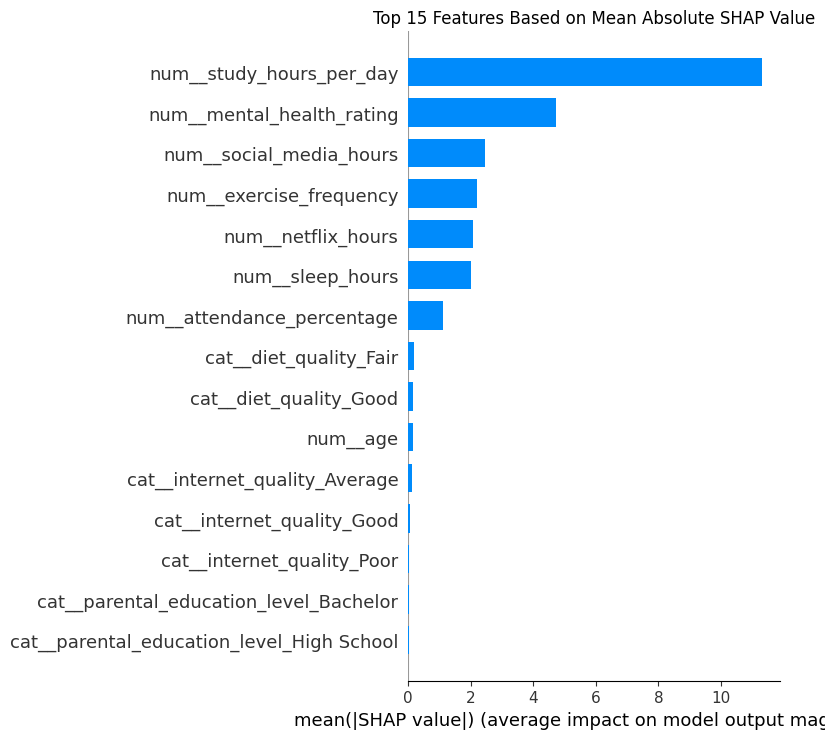

In [210]:
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_train_transformed_xgb,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title("Top 15 Features Based on Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

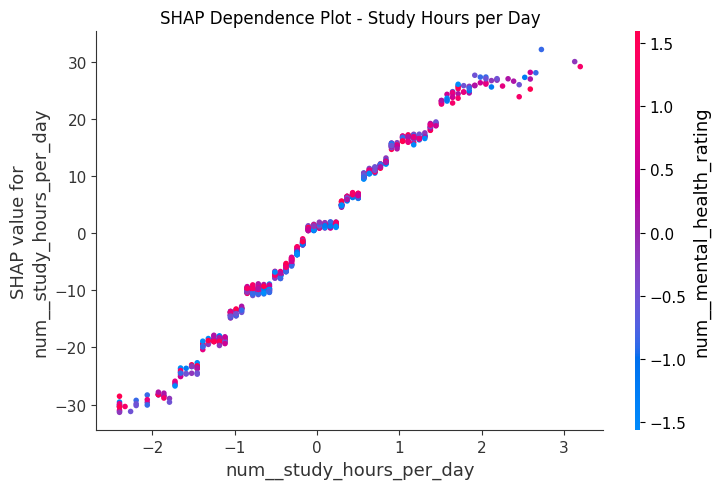

In [211]:
# SHAP Dependence Plot - Study Hours

shap.dependence_plot(
    "num__study_hours_per_day",
    shap_values,
    X_train_transformed_xgb,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Dependence Plot - Study Hours per Day")
plt.tight_layout()
plt.show()

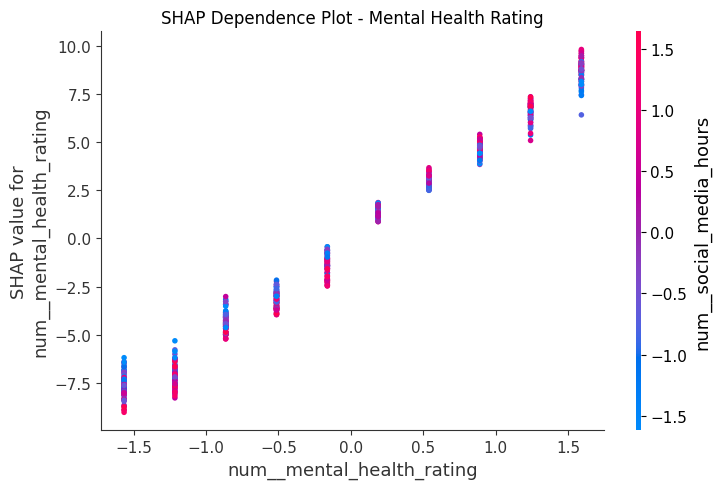

In [212]:
# SHAP Dependence Plot - Mental Health Rating

shap.dependence_plot(
    "num__mental_health_rating",
    shap_values,
    X_train_transformed_xgb,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Dependence Plot - Mental Health Rating")
plt.tight_layout()
plt.show()

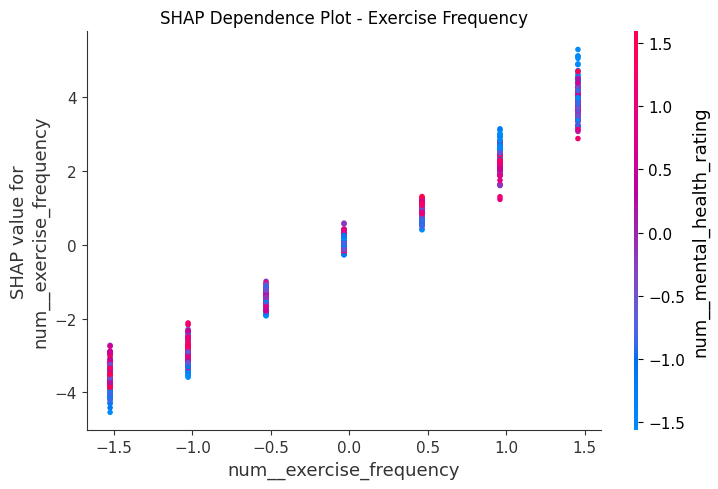

In [213]:
# SHAP Dependence Plot - Exercise Frequency

shap.dependence_plot(
    "num__exercise_frequency",
    shap_values,
    X_train_transformed_xgb,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Dependence Plot - Exercise Frequency")
plt.tight_layout()
plt.show()

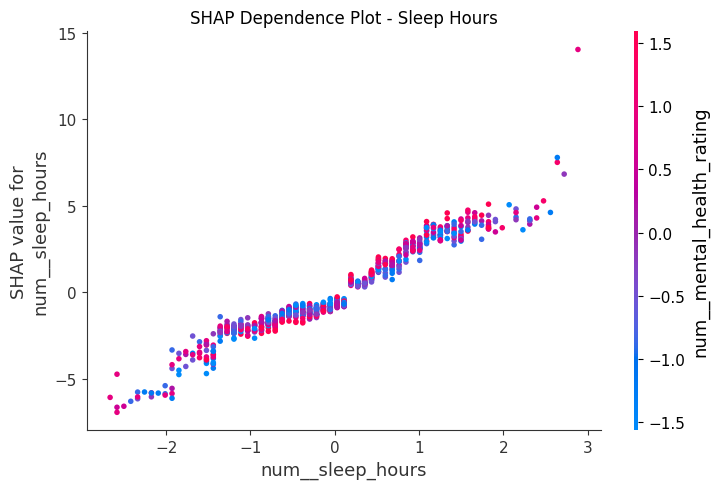

In [214]:
# SHAP Dependence Plot - Sleep Hours

shap.dependence_plot(
    "num__sleep_hours",
    shap_values,
    X_train_transformed_xgb,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Dependence Plot - Sleep Hours")
plt.tight_layout()
plt.show()

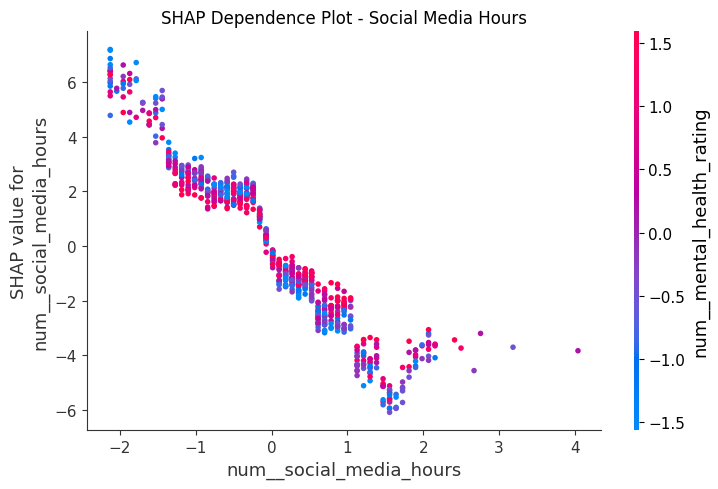

In [215]:
# SHAP Dependence Plot - Social Media Hours

shap.dependence_plot(
    "num__social_media_hours",
    shap_values,
    X_train_transformed_xgb,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Dependence Plot - Social Media Hours")
plt.tight_layout()
plt.show()

## Final Model Selection

The evaluated models were compared using cross-validation and test-set performance metrics. The final model was selected based on MAE, RMSE, R², and MAPE.

The optimized XGBoost model achieved the strongest test-set performance among the optimized models evaluated in this study and was therefore selected as the final predictive model.

The selected model was subsequently used for feature importance analysis, SHAP-based explainability, and prediction error analysis.

In [216]:
# Final comparison of optimized models

final_model_comparison = pd.DataFrame({
    "Model": [
        "Optimized Lasso",
        "Optimized XGBoost"
    ],
    "MAE": [
        4.0620,
        3.1881
    ],
    "RMSE": [
        5.0126,
        3.9312
    ],
    "R2": [
        0.9020,
        0.9397
    ],
    "MAPE": [
        6.73,
        5.13
    ]
})

final_model_comparison

,Model,MAE,RMSE,R2,MAPE
0,Optimized Lasso,4.0620,5.0126,0.9020,6.73
1,Optimized XGBoost,3.1881,3.9312,0.9397,5.13


### Final Model

The optimized XGBoost model was selected as the final model with:

- MAE: 3.1881
- RMSE: 3.9312
- R²: 0.9397
- MAPE: 5.13%

The model provides a strong balance between prediction accuracy and model interpretability. Its predictions were further examined using feature importance and SHAP analysis.